## Tải các file json ranh giới

In [2]:
# import requests

# def download_file(url, save_path):
#     print(f"Đang tải: {url}")
#     r = requests.get(url)
#     if r.status_code == 200:
#         with open(save_path, "wb") as f:
#             f.write(r.content)
#         print(f"✅ Tải xong: {save_path}")
#     else:
#         print(f"❌ Lỗi tải {url}, status code: {r.status_code}")


# if __name__ == "__main__":
#     # 1. GADM cấp tỉnh (level-1) - GeoJSON
#     gadm_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_VNM_1.json"
#     gadm_file = "gadm41_VNM_1.json"
#     download_file(gadm_url, gadm_file)

#     # 2. Sentinel-2 Grid - GeoJSON
#     s2grid_url = "https://unpkg.com/sentinel-2-grid/data/grid.json"
#     s2grid_file = "sentinel2_grid.geojson"
#     download_file(s2grid_url, s2grid_file)


## Tần suất mỗi vùng

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Optional

class Sentinel2Visualizer:
    """Trực quan hóa phân bố tần số tiles Sentinel-2 tại Đồng bằng sông Cửu Long."""
    
    # Danh sách các tỉnh Miền Tây
    MEKONG_PROVINCES = [
        'AnGiang', 'BạcLiêu', 'BếnTre', 'CàMau', 'CầnThơ', 'ĐồngTháp',
        'HậuGiang', 'KiênGiang', 'LongAn', 'SócTrăng', 'TiềnGiang',
        'TràVinh', 'VĩnhLong'
    ]
    
    def __init__(self, df: pd.DataFrame, vietnam_file: str = "gadm41_VNM_1.json",
                   mgrs_file: str = "sentinel2_grid.geojson", title: str = "Phân bố Tiles Sentinel-2 tại Đồng bằng sông Cửu Long"):
        """
        Khởi tạo Visualizer.
        
        Args:
            df: DataFrame chứa cột 'MGRS_Tile' và 'Frequency'
            vietnam_file: Đường dẫn file ranh giới Việt Nam (GADM)
            mgrs_file: Đường dẫn file lưới Sentinel-2 (GeoJSON)
        """
        self.df = df
        self.vietnam_file = vietnam_file
        self.mgrs_file = mgrs_file
        self.vietnam_gdf = None
        self.mgrs_gdf = None
        self.mekong_gdf = None
        self.merged_gdf = None
        self.title = title
    
    def load_geographic_data(self) -> None:
        """Tải dữ liệu địa lý từ file."""
        try:
            # Đọc GeoJSON/Shapefile cho ranh giới Việt Nam và lưới MGRS
            self.vietnam_gdf = gpd.read_file(self.vietnam_file)
            self.mgrs_gdf = gpd.read_file(self.mgrs_file)
        except Exception as e:
            raise FileNotFoundError(
                f"Không thể tải tập tin địa lý. Kiểm tra tên file và đường dẫn.\n"
                f"Chi tiết: {e}"
            )
    
    def standardize_column_names(self) -> None:
        """Chuẩn hóa tên cột MGRS_Tile trong lưới MGRS."""
        name_mappings = {'Name': 'MGRS_Tile', 'name': 'MGRS_Tile'}
        
        for old_name, new_name in name_mappings.items():
            if old_name in self.mgrs_gdf.columns:
                self.mgrs_gdf = self.mgrs_gdf.rename(columns={old_name: new_name})
                break
        
        # Đảm bảo cột cần thiết cho việc merge tồn tại trong df
        if 'MGRS_Tile' not in self.df.columns:
             raise ValueError("DataFrame đầu vào phải có cột 'MGRS_Tile'.")
    
    def filter_mekong_region(self) -> None:
        """Lọc khu vực Đồng bằng sông Cửu Long."""
        self.mekong_gdf = self.vietnam_gdf[
            self.vietnam_gdf['NAME_1'].isin(self.MEKONG_PROVINCES)
        ].copy()
        
        # Đồng bộ hệ tọa độ
        target_crs = self.mgrs_gdf.crs
        self.mekong_gdf = self.mekong_gdf.to_crs(target_crs)
    
    def filter_and_merge_tiles(self) -> gpd.GeoDataFrame:
        """Lọc và nối dữ liệu tiles MGRS với tần số."""
        # Lọc tiles có dữ liệu trong DataFrame đầu vào
        tiles_list = self.df['MGRS_Tile'].tolist()
        mgrs_filtered = self.mgrs_gdf[
            self.mgrs_gdf['MGRS_Tile'].isin(tiles_list)
        ].copy()
        
        # Spatial join để tìm tiles giao với khu vực Miền Tây
        mgrs_in_region = gpd.sjoin(
            mgrs_filtered,
            self.mekong_gdf,
            how='inner',
            predicate='intersects'
        )
        
        # Loại bỏ trùng lặp nếu một tile nằm trên nhiều tỉnh
        mgrs_unique = mgrs_in_region.drop_duplicates(
            subset=['MGRS_Tile']
        )[['MGRS_Tile', 'geometry']].copy()
        
        # Nối với dữ liệu tần số
        self.merged_gdf = mgrs_unique.merge(
            self.df[['MGRS_Tile', 'Frequency']],
            on='MGRS_Tile',
            how='left'
        )
        
        return self.merged_gdf
    
    def calculate_map_bounds(self, padding: float = 0.1) -> Tuple[float, float, float, float]:
        """Tính toán phạm vi hiển thị bản đồ."""
        if self.mekong_gdf.empty:
            raise ValueError("Không có dữ liệu khu vực để hiển thị")
        
        minx, miny, maxx, maxy = self.mekong_gdf.total_bounds
        dx = (maxx - minx) * padding
        dy = (maxy - miny) * padding * 2 # Tăng padding dọc
        
        return (minx - dx, miny - dy, maxx + dx, maxy + dy)
    
    def plot_map(self, figsize: Tuple[int, int] = (15, 10), 
                   cmap: str = 'OrRd', fontsize: int = 9) -> None:
        """
        Vẽ bản đồ phân bố tần số tiles.
        
        Args:
            figsize: Kích thước figure (width, height)
            cmap: Colormap cho biểu đồ nhiệt (ví dụ: 'viridis', 'Blues', 'Reds')
            fontsize: Kích thước font chữ nhãn
        """
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # 1. Vẽ nền ranh giới khu vực Miền Tây
        self.mekong_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='none')
        self.mekong_gdf.boundary.plot(
            ax=ax, color='#333333', linewidth=1.5, 
            label='Ranh giới Miền Tây'
        )
        
        # 2. Vẽ heatmap tiles
        vmin = self.merged_gdf['Frequency'].min()
        vmax = self.merged_gdf['Frequency'].max()
        
        self.merged_gdf.plot(
            column='Frequency',
            ax=ax,
            legend=True,
            cmap=cmap, # SỬ DỤNG COLOR MAP TÙY CHỌN
            vmin=vmin,
            vmax=vmax,
            linewidth=0.8,
            edgecolor='black',
            legend_kwds={
                'label': 'Giá trị',
                'orientation': 'horizontal',
                'shrink': 0.6,
                'pad': 0.05
            }
        )
        
        # 3. Thêm nhãn tiles
        self._add_tile_labels(ax, fontsize)
        
        # 4. Thiết lập phạm vi hiển thị
        minx, miny, maxx, maxy = self.calculate_map_bounds()
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        
        # 5. Tùy chỉnh hiển thị
        ax.set_title(
            self.title,
            fontsize=14, pad=10
        )
        ax.set_xlabel('Kinh độ')
        ax.set_ylabel('Vĩ độ')
        ax.grid(False)
        ax.set_aspect('equal')
        # ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False)
        
        plt.tight_layout()
        plt.show()
    
    def _add_tile_labels(self, ax, fontsize: int) -> None:
        """Thêm nhãn tên và tần số cho mỗi tile."""
        for _, row in self.merged_gdf.iterrows():
            if row.geometry is not None:
                centroid = row.geometry.centroid
                # Chắc chắn rằng 'Frequency' là số để làm tròn
                freq = row['Frequency'] if pd.notna(row['Frequency']) else 0
                freq = round(freq, 2)
                label = f"{row['MGRS_Tile']}\n({freq})"
                
                ax.text(
                    centroid.x, centroid.y, label,
                    ha='center', va='center', fontsize=fontsize,
                    bbox={
                        'facecolor': 'white',
                        'alpha': 0.8,
                        'pad': 2,
                        'edgecolor': 'none'
                    }
                )
    
    def run(self, custom_cmap: Optional[str] = None) -> None:
        """
        Chạy toàn bộ quy trình visualization.
        
        Args:
            custom_cmap: Tên colormap tùy chỉnh (ví dụ: 'viridis').
        """
        # print("Bắt đầu xử lý...")
        
        # Bước 1: Tải dữ liệu địa lý
        self.load_geographic_data()
        self.standardize_column_names()
        
        # Bước 2: Lọc khu vực Miền Tây
        self.filter_mekong_region()
        # print(f"✓ Lọc khu vực: {len(self.mekong_gdf)} tỉnh")
        
        # Bước 3: Lọc và nối dữ liệu
        self.filter_and_merge_tiles()
        # print(f"✓ Nối dữ liệu: {len(self.merged_gdf)} tiles trong khu vực")
        
        # Bước 4: Vẽ bản đồ
        # Sử dụng cmap tùy chỉnh nếu được cung cấp, nếu không thì dùng mặc định 'OrRd'
        self.plot_map(cmap=custom_cmap if custom_cmap else 'OrRd')

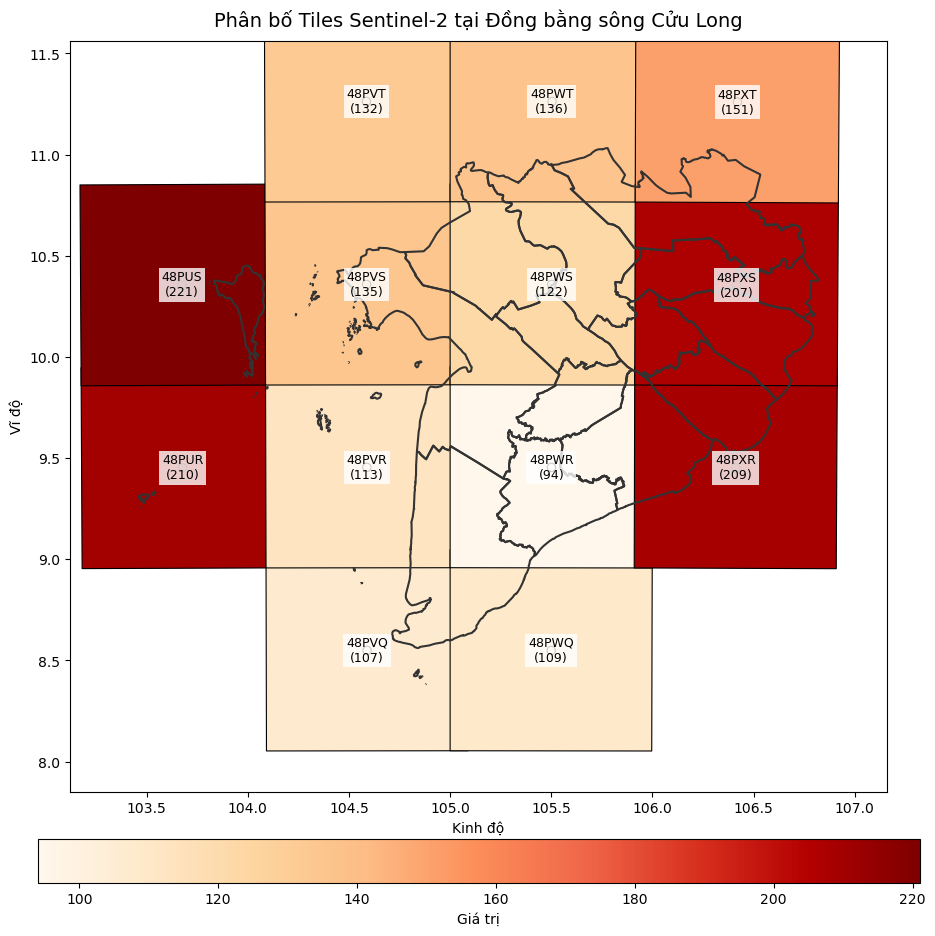

In [4]:
meta_data = r".\bounding_boxes\sentinel-2_2019-2024_bounding_boxes.csv"
df = pd.read_csv(meta_data)
df = df.iloc[1204:, :]
df['area'] = df['image_id'].str[-5:]
df_frequency = df['area'].value_counts().reset_index()
df_frequency.columns = ['MGRS_Tile', 'Frequency']
visualizer = Sentinel2Visualizer(
    df=df_frequency,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson"
)

visualizer.run()

Các ảnh vệ tinh chủ yếu tập trung ở các tính phía Đông, do một số tính chất của khu vực biển nên thường là đối tượng quan trắc trọng điểm, kèm theo những khu vực này ít bị mây che hơn so với các tỉnh phía Tây

## Lọc Features

### Các Đặc Trưng Khí Quyển, Bề Mặt và Bức Xạ trong Ảnh Vệ Tinh

🌍 Đặc trưng khí quyển - ảnh hưởng đến sự cân bằng năng lượng Trái Đất
- **GRANULE_MEAN_AOT (2022+)** 
  Độ đo Aerosol Optical Thickness (AOT trung bình) – thể hiện độ dày của các hạt khí dung ngăn chặn ánh sáng Mặt Trời.  
  → Thước đo quan trọng về ô nhiễm không khí và khí hậu.

- **GRANULE_MEAN_WV (2022+)**  
  Giá trị trung bình hơi nước trong khí quyển.  
  → Ảnh hưởng trực tiếp đến lượng mưa và khí hậu.

- **OZONE_VALUE (2022+)**  
  Giá trị ozon tầng bình lưu.  
  → Tác động mạnh đến nhiệt độ khí quyển và bảo vệ Trái Đất khỏi tia cực tím (UV).

- **CLOUDY_PIXEL_PERCENTAGE**  
  Tỉ lệ pixel bị mây che phủ (mọi loại mây).  
  → Quyết định lượng bức xạ Mặt Trời đến được bề mặt Trái Đất.

- **THIN_CIRRUS_PERCENTAGE**  
  Tỉ lệ pixel có mây cirrus mỏng (tầng cao, bán trong suốt).  
  → Ảnh hưởng đến lượng bức xạ thoát ra ngoài không gian.

---

🏞️ Đặc trưng bề mặt
- **VEGETATION_PERCENTAGE**  
  Tỉ lệ pixel là thảm thực vật.  
  → Ảnh hưởng đến phản xạ, hấp thụ nhiệt, và thoát hơi nước.

- **WATER_PERCENTAGE**  
  Tỉ lệ pixel là mặt nước.  
  → Ảnh hưởng đến trao đổi nhiệt và độ ẩm.

- **SNOW_ICE_PERCENTAGE**  
  Tỉ lệ pixel là băng tuyết.  
  → Ảnh hưởng mạnh đến phản xạ ánh sáng (albedo).  
  → Biến động ở chỉ số này liên quan chặt chẽ đến biến đổi khí hậu.

---

☀️ Đặc trưng bức xạ
- **MEAN_SOLAR_ZENITH_ANGLE**  
  Góc thiên đỉnh Mặt Trời trung bình.  
  → Cơ sở để tính toán lượng năng lượng bức xạ.

## Đơn biến

### Set up

In [5]:
import json
import os
import glob
from pathlib import Path
from typing import List, Dict, Optional, Union
import pandas as pd
from tqdm import tqdm


class JSONFeatureExtractor:
    """Trích xuất features từ các file JSON."""

    # Danh sách features mặc định cho Sentinel-2 metadata
    DEFAULT_SENTINEL2_FEATURES = [
        "PRODUCT_ID",
        "GRANULE_MEAN_AOT",
        "GRANULE_MEAN_WV",
        "OZONE_VALUE",
        "CLOUDY_PIXEL_PERCENTAGE",
        "THIN_CIRRUS_PERCENTAGE",
        "VEGETATION_PERCENTAGE",
        "MEAN_SOLAR_ZENITH_ANGLE",
        "WATER_PERCENTAGE",
        "SNOW_ICE_PERCENTAGE",
    ]

    def __init__(self, features: Optional[List[str]] = None, verbose: bool = True):
        """
        Khởi tạo Feature Extractor.

        Args:
            features: Danh sách features cần trích xuất.
                     Nếu None, sử dụng DEFAULT_SENTINEL2_FEATURES
            verbose: Hiển thị thông báo chi tiết
        """
        self.features = features or self.DEFAULT_SENTINEL2_FEATURES
        self.verbose = verbose
        self.errors = []

    def load_json_file(self, filepath: Union[str, Path]) -> Optional[Dict]:
        """
        Load một file JSON.

        Args:
            filepath: Đường dẫn tới file JSON

        Returns:
            Dict nếu thành công, None nếu có lỗi
        """
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                return json.load(f)
        except FileNotFoundError:
            self.errors.append(("FileNotFound", str(filepath)))
            if self.verbose:
                print(f"⚠️  Không tìm thấy: {filepath}")
            return None
        except json.JSONDecodeError as e:
            self.errors.append(("JSONDecodeError", str(filepath), str(e)))
            if self.verbose:
                print(f"⚠️  JSON không hợp lệ: {filepath}")
            return None
        except Exception as e:
            self.errors.append(("UnknownError", str(filepath), str(e)))
            if self.verbose:
                print(f"⚠️  Lỗi không xác định: {filepath} - {e}")
            return None

    def extract_record(
        self, data: Union[Dict, List], source_file: str = ""
    ) -> List[Dict]:
        """
        Trích xuất records từ dữ liệu JSON.

        Args:
            data: Dữ liệu JSON (dict hoặc list)
            source_file: Tên file nguồn (để ghi log)

        Returns:
            List các records đã trích xuất
        """
        records = []

        if isinstance(data, dict):
            record = self._extract_features_from_dict(data)
            record["_source_file"] = source_file  # Thêm thông tin file nguồn
            records.append(record)

        elif isinstance(data, list):
            for idx, item in enumerate(data):
                if isinstance(item, dict):
                    record = self._extract_features_from_dict(item)
                    record["_source_file"] = source_file
                    record["_list_index"] = idx
                    records.append(record)
                else:
                    if self.verbose:
                        print(
                            f"⚠️  Item không phải dict trong {source_file}: {type(item)}"
                        )
        else:
            if self.verbose:
                print(f"⚠️  Định dạng không hỗ trợ trong {source_file}: {type(data)}")

        return records

    def _extract_features_from_dict(self, data: Dict) -> Dict:
        """
        Trích xuất features từ một dictionary.

        Args:
            data: Dictionary chứa dữ liệu

        Returns:
            Dict chứa các features đã trích xuất
        """
        return {feat: data.get(feat) for feat in self.features}

    def extract_from_files(
        self, file_paths: List[str], add_metadata: bool = True
    ) -> pd.DataFrame:
        """
        Trích xuất features từ danh sách file.

        Args:
            file_paths: Danh sách đường dẫn file JSON
            add_metadata: Thêm cột metadata (source file, etc.)

        Returns:
            DataFrame chứa features đã trích xuất
        """
        self.errors = []  # Reset errors
        all_records = []

        iterator = (
            tqdm(file_paths, desc="Trích xuất features") if self.verbose else file_paths
        )

        for filepath in iterator:
            data = self.load_json_file(filepath)

            if data is not None:
                records = self.extract_record(data, source_file=str(filepath))
                all_records.extend(records)

        df = pd.DataFrame(all_records)

        # Loại bỏ cột metadata nếu không cần
        if not add_metadata and "_source_file" in df.columns:
            df = df.drop(columns=["_source_file", "_list_index"], errors="ignore")

        if self.verbose:
            self._print_summary(df)

        return df

    def _print_summary(self, df: pd.DataFrame) -> None:
        """In tóm tắt kết quả."""
        print(f"\n{'='*60}")
        print(f"✓ Trích xuất hoàn tất:")
        print(f"  - Tổng số records: {len(df)}")
        print(f"  - Tổng số features: {len(self.features)}")
        print(f"  - Số lỗi: {len(self.errors)}")

        # Kiểm tra giá trị null
        null_counts = df[self.features].isnull().sum()
        if null_counts.sum() > 0:
            print(f"\n⚠️  Features có giá trị null:")
            for feat, count in null_counts[null_counts > 0].items():
                print(f"    - {feat}: {count} ({count/len(df)*100:.1f}%)")

        print(f"{'='*60}\n")

    def get_error_summary(self) -> pd.DataFrame:
        """
        Lấy tóm tắt các lỗi đã gặp.

        Returns:
            DataFrame chứa thông tin lỗi
        """
        if not self.errors:
            return pd.DataFrame()

        error_df = pd.DataFrame(self.errors, columns=["error_type", "file", "details"])
        return error_df


class FilePathFilter:
    """Lọc file paths theo các tiêu chí."""

    @staticmethod
    def find_files(pattern: str, recursive: bool = True) -> List[str]:
        """
        Tìm files theo pattern.

        Args:
            pattern: Glob pattern
            recursive: Tìm kiếm đệ quy

        Returns:
            List đường dẫn file
        """
        return glob.glob(pattern, recursive=recursive)

    @staticmethod
    def exclude_by_year(
        file_paths: List[str], exclude_years: List[int], year_position: int = 1
    ) -> List[str]:
        """
        Loại trừ files theo năm trong đường dẫn.

        Args:
            file_paths: Danh sách file paths
            exclude_years: Danh sách năm cần loại trừ
            year_position: Vị trí thư mục năm trong path (mặc định: 1)

        Returns:
            List file paths đã lọc
        """
        filtered = []
        exclude_year_strs = [str(year) for year in exclude_years]

        for filepath in file_paths:
            parts = os.path.normpath(filepath).split(os.sep)
            if year_position < len(parts):
                year_dir = parts[year_position]
                # Kiểm tra xem thư mục có bắt đầu bằng năm cần loại trừ không
                if not any(year_dir.startswith(y) for y in exclude_year_strs):
                    filtered.append(filepath)
            else:
                filtered.append(filepath)

        return filtered

    @staticmethod
    def exclude_by_pattern(
        file_paths: List[str], exclude_patterns: List[str]
    ) -> List[str]:
        """
        Loại trừ files theo pattern.

        Args:
            file_paths: Danh sách file paths
            exclude_patterns: Danh sách patterns cần loại trừ

        Returns:
            List file paths đã lọc
        """
        filtered = []
        for filepath in file_paths:
            if not any(pattern in filepath for pattern in exclude_patterns):
                filtered.append(filepath)
        return filtered


# ============================================================================
# SỬ DỤNG
# ============================================================================


def main():
    """Ví dụ sử dụng."""

    # Bước 1: Tìm tất cả file metadata
    pattern = r"dbscl-sentinel-2-*/*/*/*_metadata.json"
    all_files = FilePathFilter.find_files(pattern, recursive=True)
    print(f"Tìm thấy {len(all_files)} files")

    # Bước 2: Lọc file (loại trừ năm 2019, 2020)
    filtered_files = FilePathFilter.exclude_by_year(
        all_files, exclude_years=[2019, 2020], year_position=1
    )
    print(f"Còn lại {len(filtered_files)} files sau khi lọc")

    # Bước 3: Trích xuất features
    extractor = JSONFeatureExtractor(
        features=None, verbose=True  # Sử dụng DEFAULT_SENTINEL2_FEATURES
    )

    df = extractor.extract_from_files(filtered_files, add_metadata=True)
    df["AREA"] = df["PRODUCT_ID"].str[-21:-16]  # Lấy MGRS tile từ PRODUCT_ID

    # Bước 4: Xem kết quả
    print("\nMẫu dữ liệu:")
    print(df.head())

    print("\nThông tin DataFrame:")
    print(df.info())

    # Bước 5: Kiểm tra lỗi (nếu có)
    errors_df = extractor.get_error_summary()
    if not errors_df.empty:
        print("\nTóm tắt lỗi:")
        print(errors_df.groupby("error_type").size())

    # Bước 6: Lưu kết quả
    output_file = "sentinel2_features.csv"
    df.to_csv(output_file, index=False)
    print(f"\n✓ Đã lưu kết quả vào: {output_file}")

    return df


if __name__ == "__main__":
    df = main()

Tìm thấy 3150 files
Còn lại 3150 files sau khi lọc


Trích xuất features: 100%|██████████| 3150/3150 [00:50<00:00, 62.48it/s] 



✓ Trích xuất hoàn tất:
  - Tổng số records: 3150
  - Tổng số features: 10
  - Số lỗi: 0

⚠️  Features có giá trị null:
    - GRANULE_MEAN_AOT: 1782 (56.6%)
    - GRANULE_MEAN_WV: 1782 (56.6%)
    - OZONE_VALUE: 1782 (56.6%)


Mẫu dữ liệu:
                                          PRODUCT_ID  GRANULE_MEAN_AOT  \
0  S2B_MSIL2A_20190106T032129_N0211_R118_T48PXT_2...               NaN   
1  S2B_MSIL2A_20190106T032129_N0211_R118_T48PWT_2...               NaN   
2  S2B_MSIL2A_20190106T032129_N0211_R118_T48PVT_2...               NaN   
3  S2B_MSIL2A_20190106T032129_N0211_R118_T48PXS_2...               NaN   
4  S2B_MSIL2A_20190106T032129_N0211_R118_T48PWS_2...               NaN   

   GRANULE_MEAN_WV  OZONE_VALUE  CLOUDY_PIXEL_PERCENTAGE  \
0              NaN          NaN                 0.294384   
1              NaN          NaN                 0.229114   
2              NaN          NaN                 4.792753   
3              NaN          NaN                 1.753549   
4              

In [6]:
import pandas as pd
from tqdm import tqdm

df = pd.read_csv("sentinel2_features.csv")
df["YEAR"] = df["PRODUCT_ID"].str[11:15]

# Danh sách cột cần xử lý
cols = [c for c in df.columns if c not in ["PRODUCT_ID", "_source_file", "AREA", "YEAR"]]
print(f"→ Tính trung bình cho {len(cols)} đặc trưng...")

# Tính trung bình & lưu từng file
for col in tqdm(cols, desc="Đang xử lý"):
    (
        df.groupby(["AREA", "YEAR"], as_index=False)[col]
        .mean()
        .to_csv(f"mean_{col}.csv", index=False)
    )

print("✓ Hoàn tất.")


→ Tính trung bình cho 9 đặc trưng...


Đang xử lý: 100%|██████████| 9/9 [00:00<00:00, 29.75it/s]

✓ Hoàn tất.


### GRANULE_MEAN_AOT

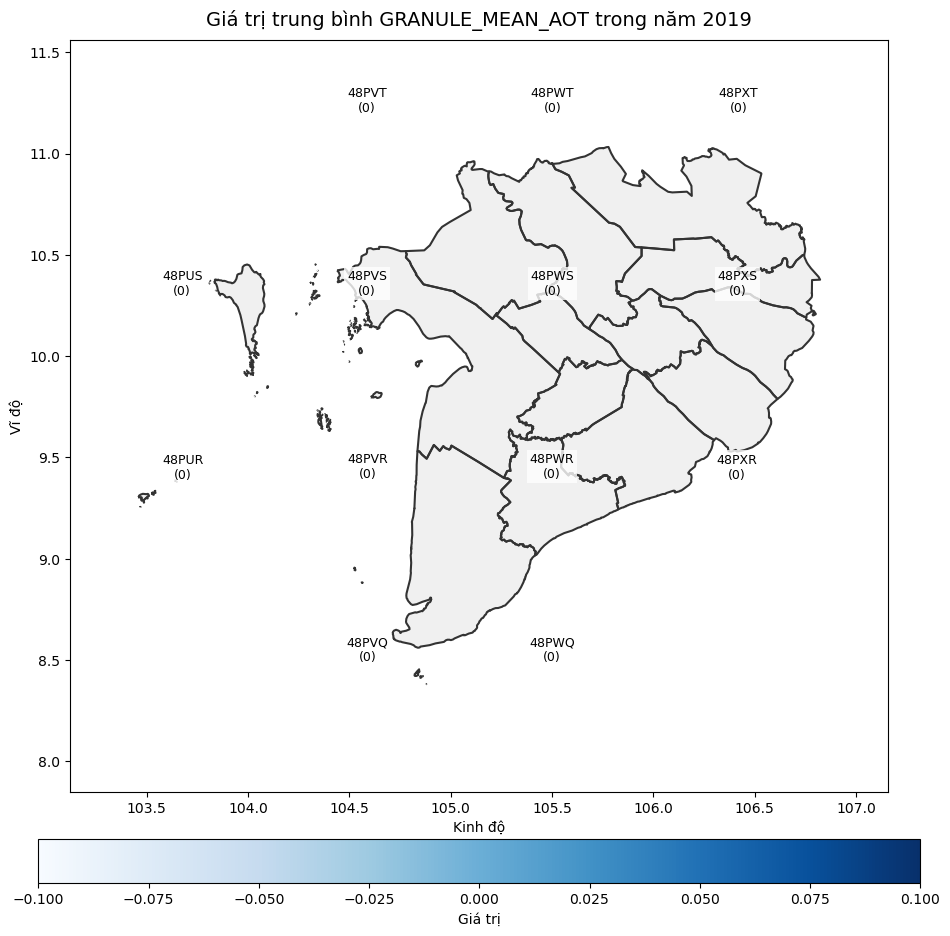

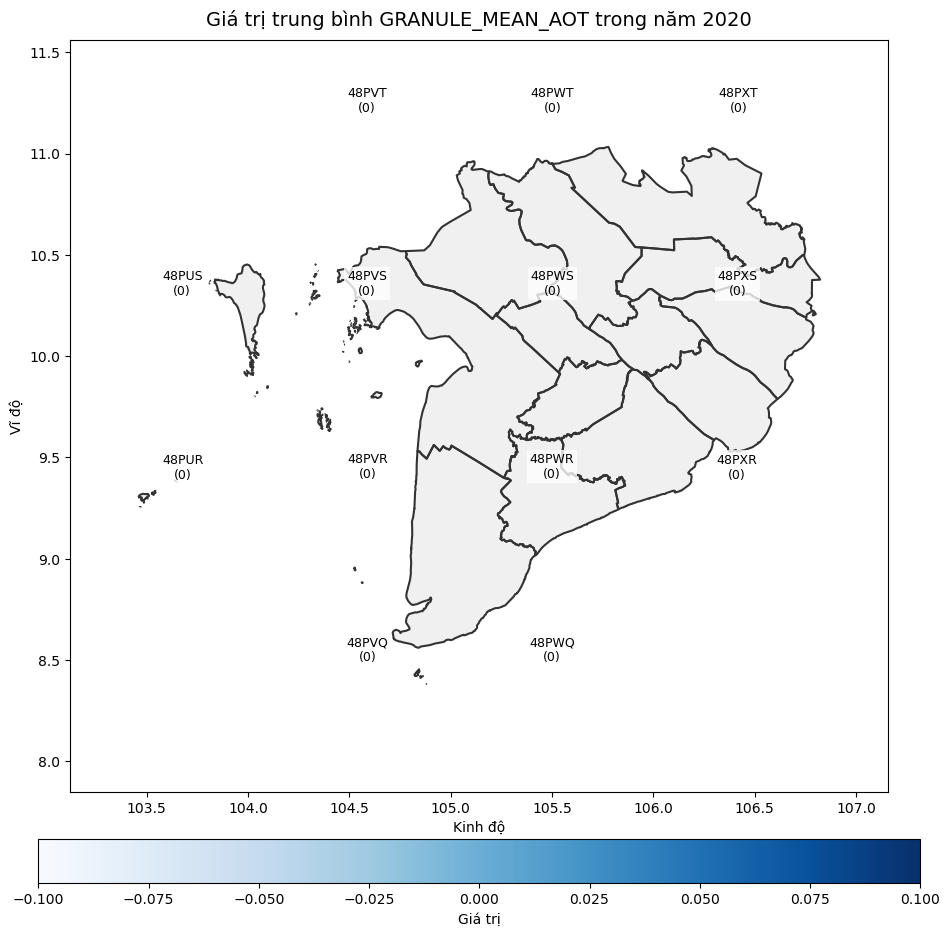

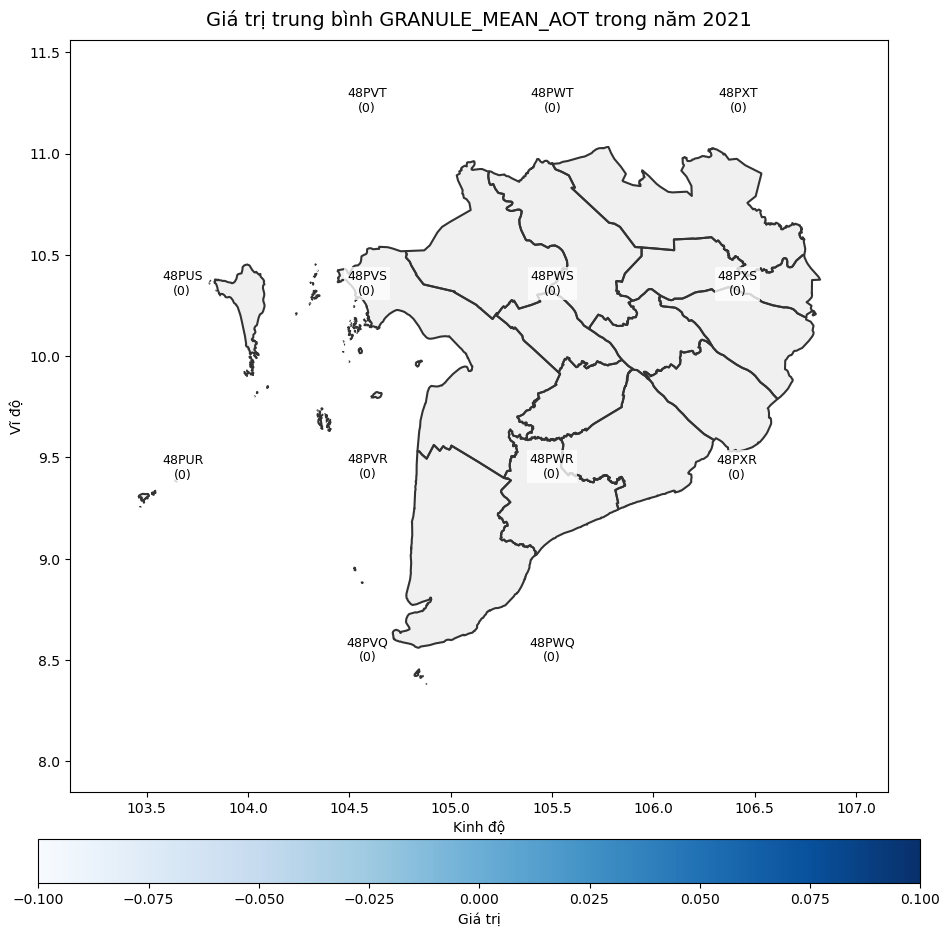

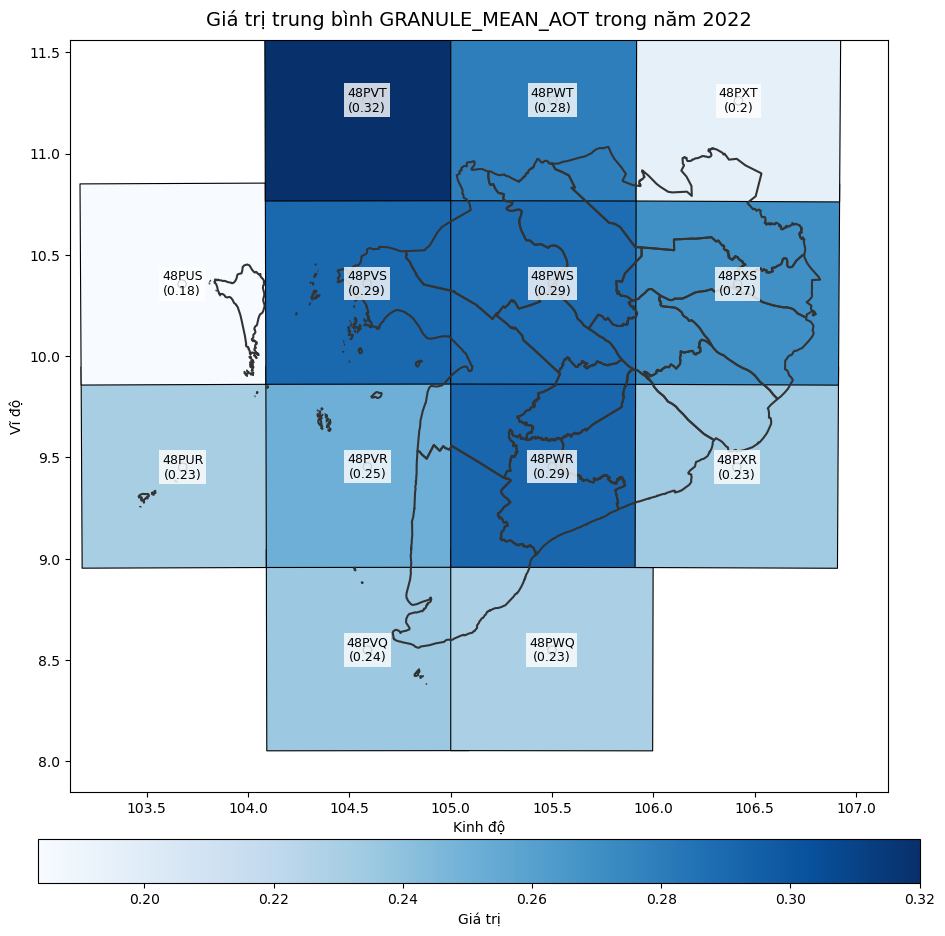

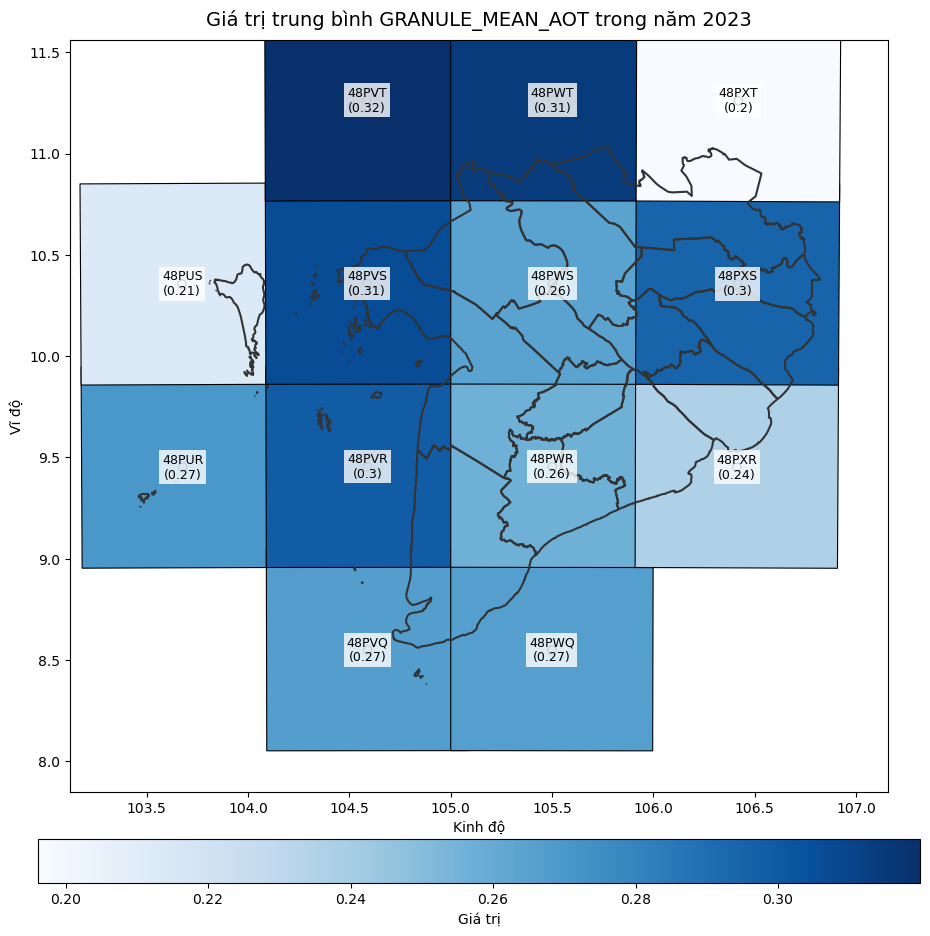

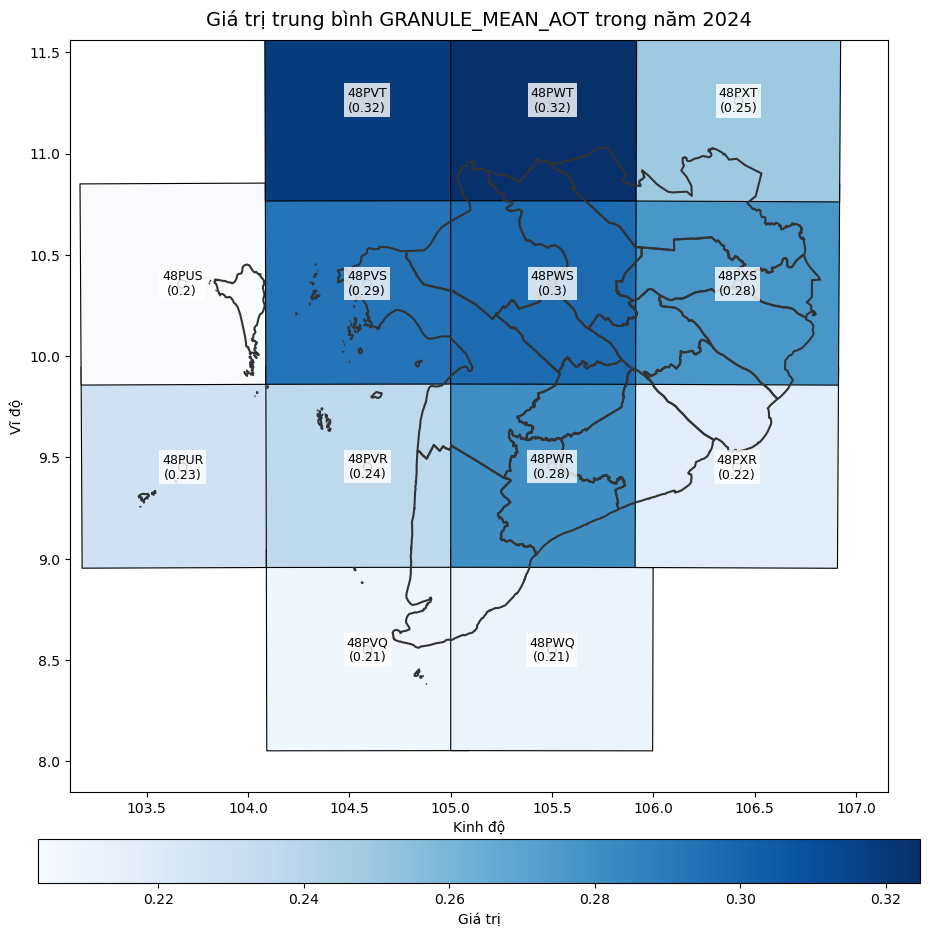

In [7]:
file = 'mean_GRANULE_MEAN_AOT.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

### CLOUD_PIXEL_PERCENTAGE

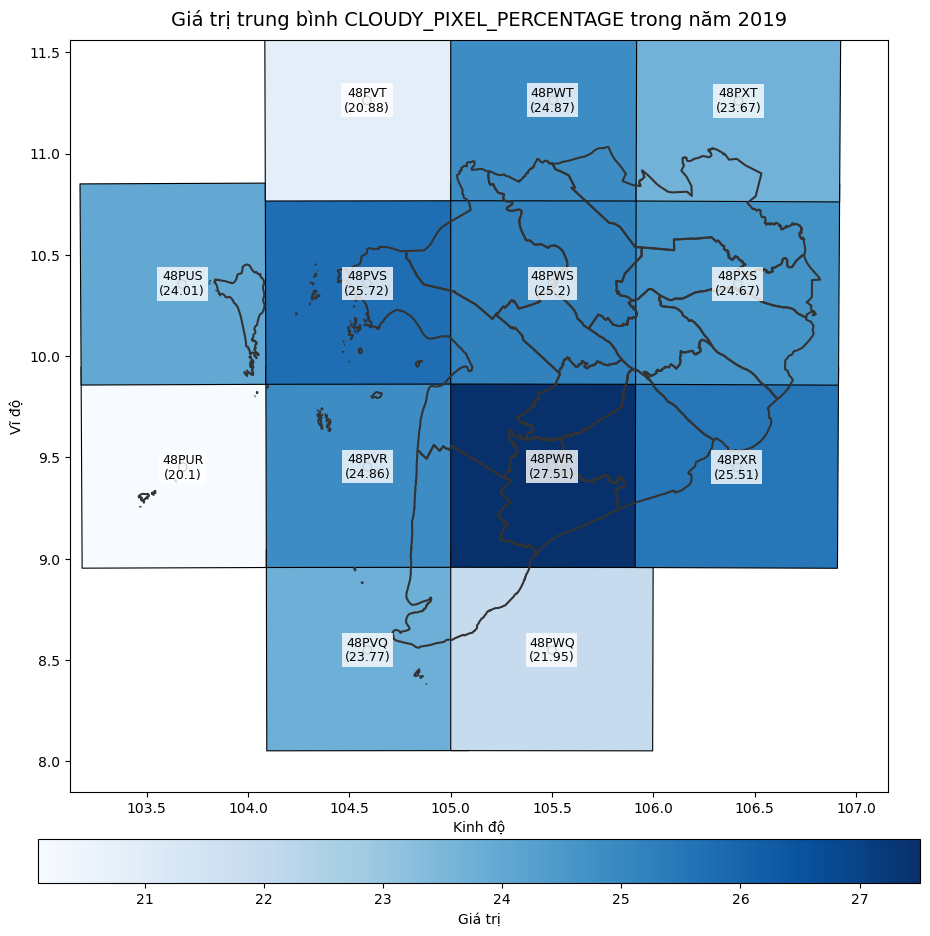

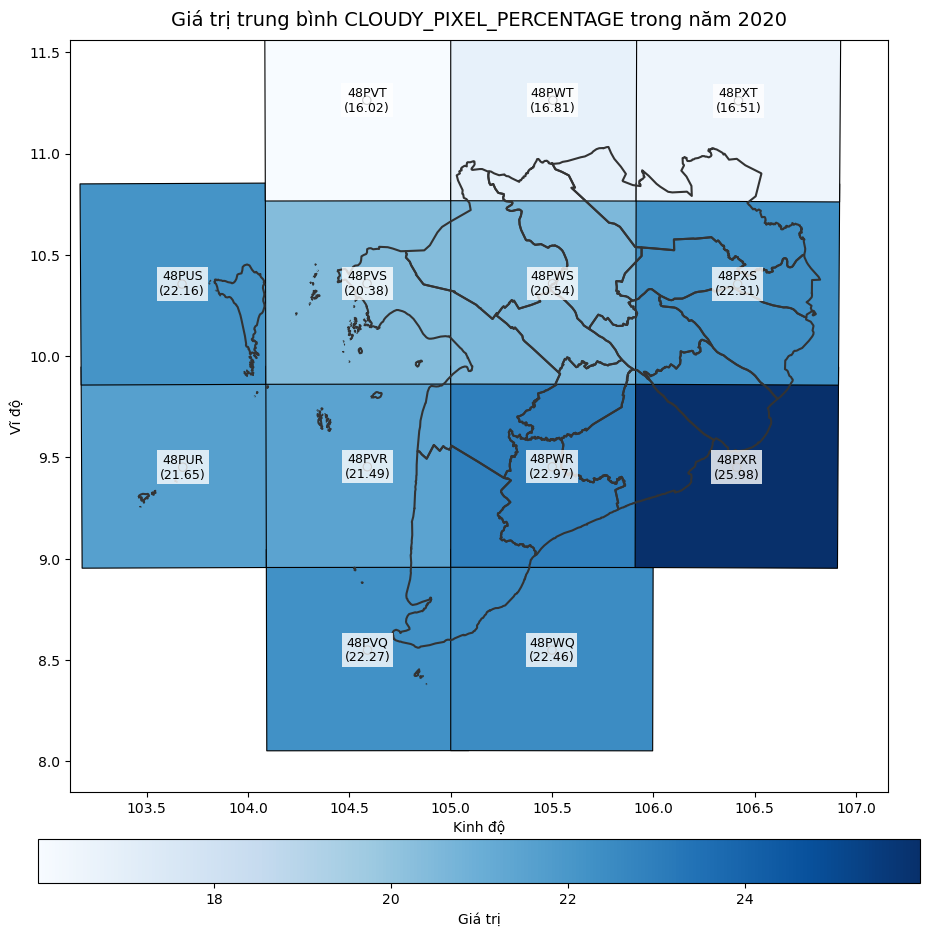

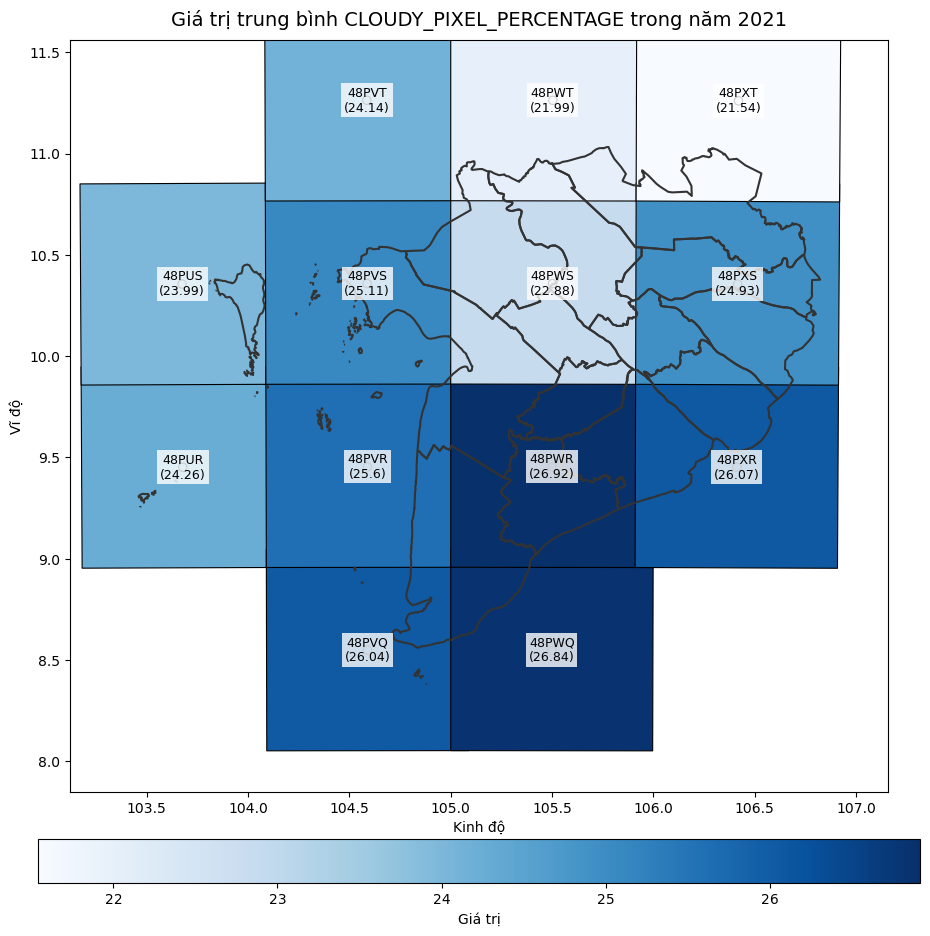

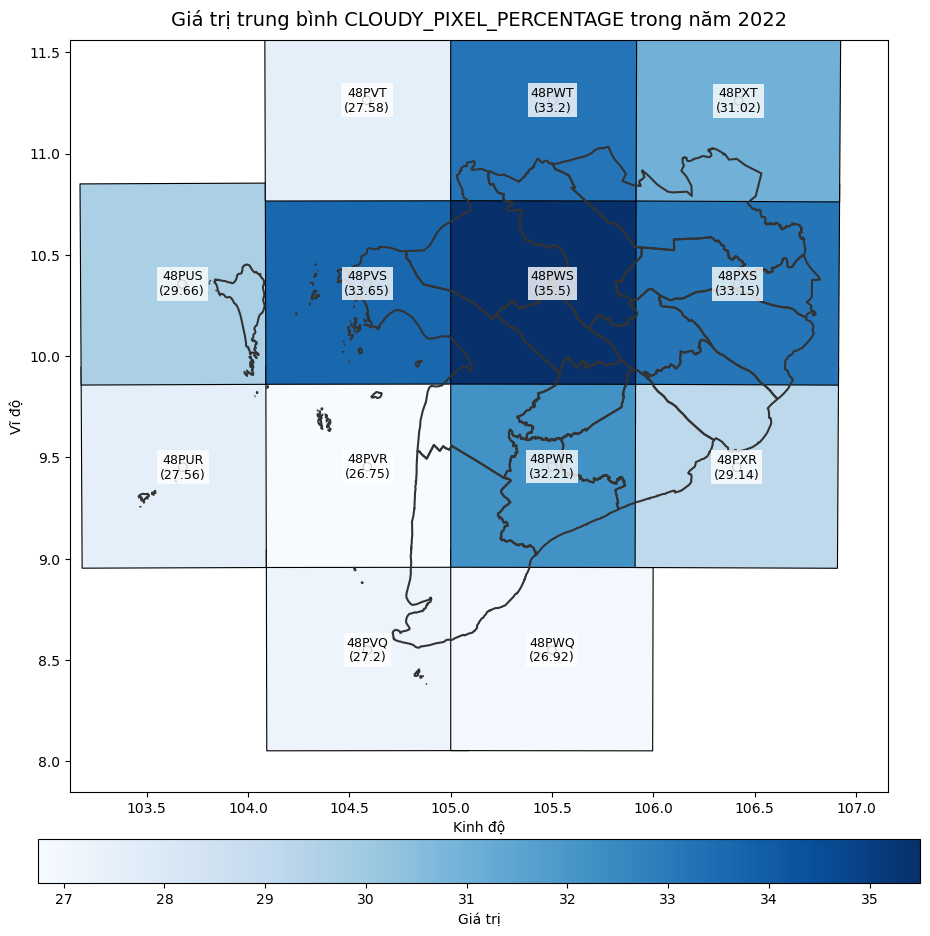

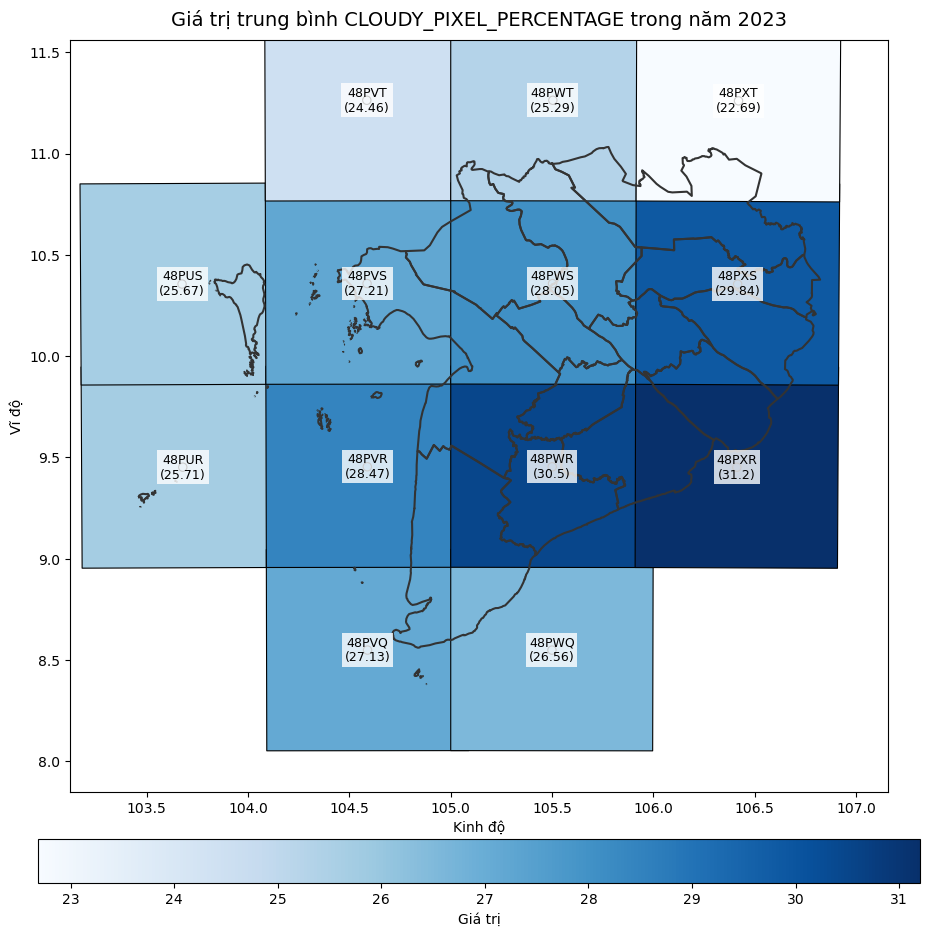

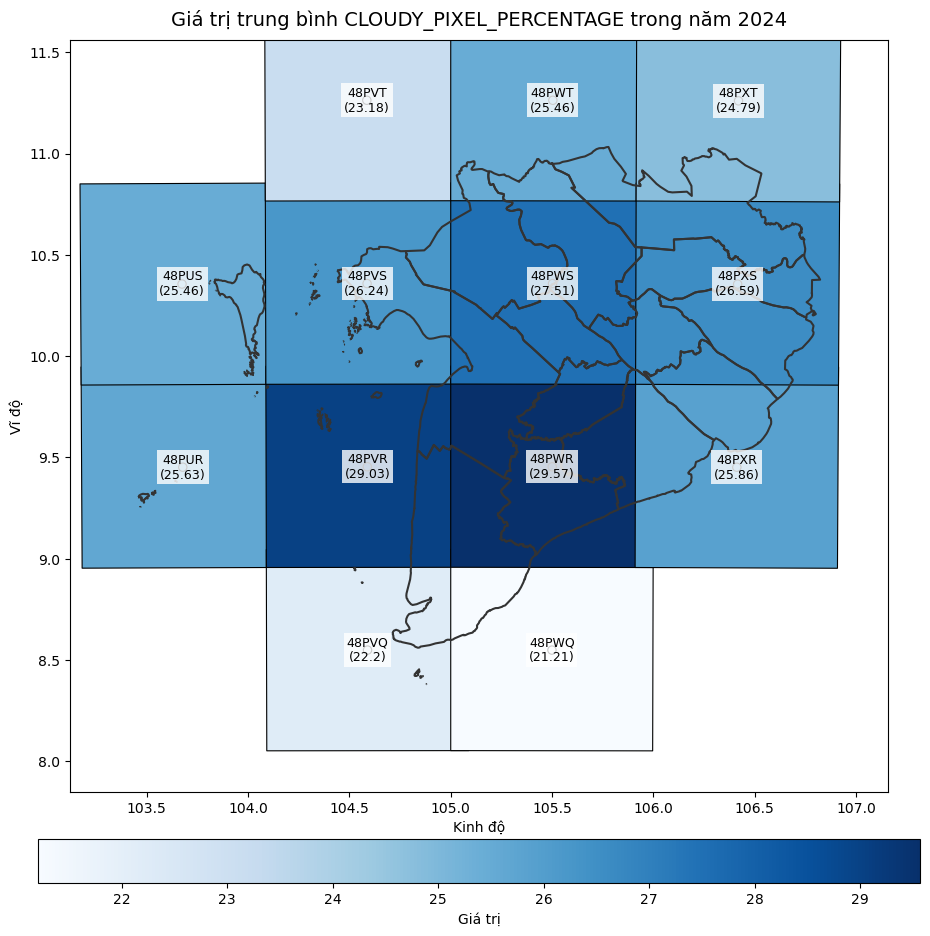

In [8]:
file = 'mean_CLOUDY_PIXEL_PERCENTAGE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

### GRANULE_MEAN_WV

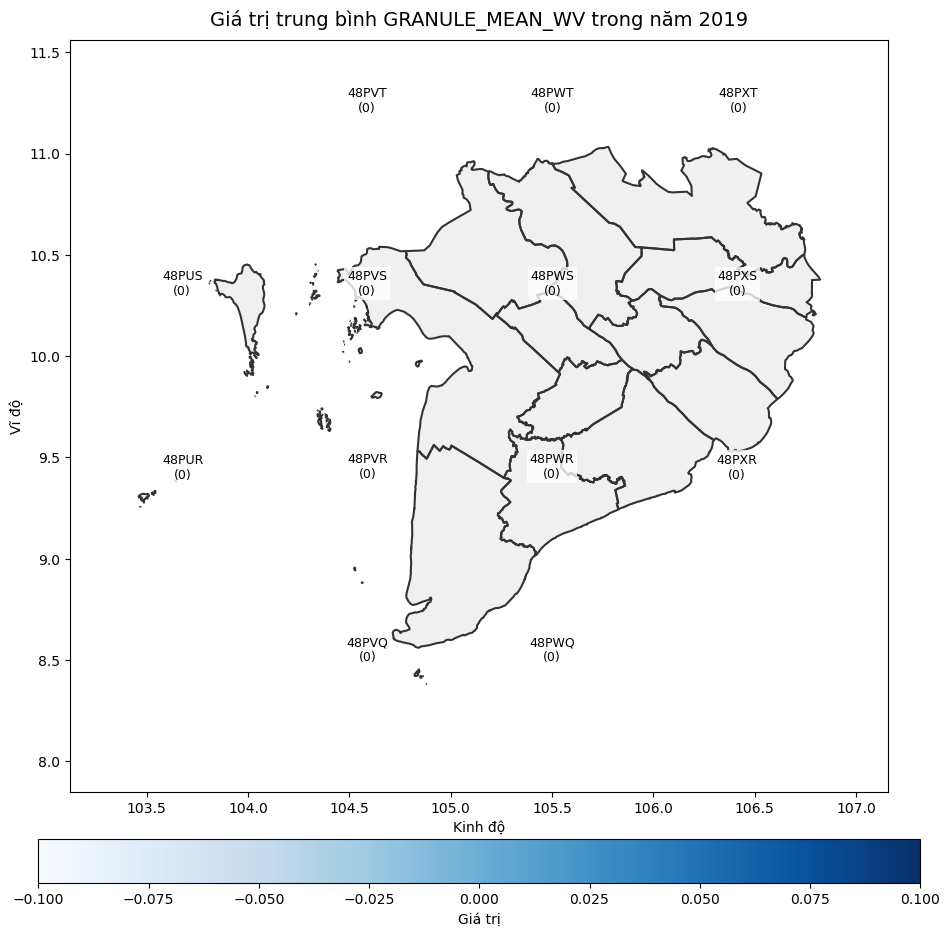

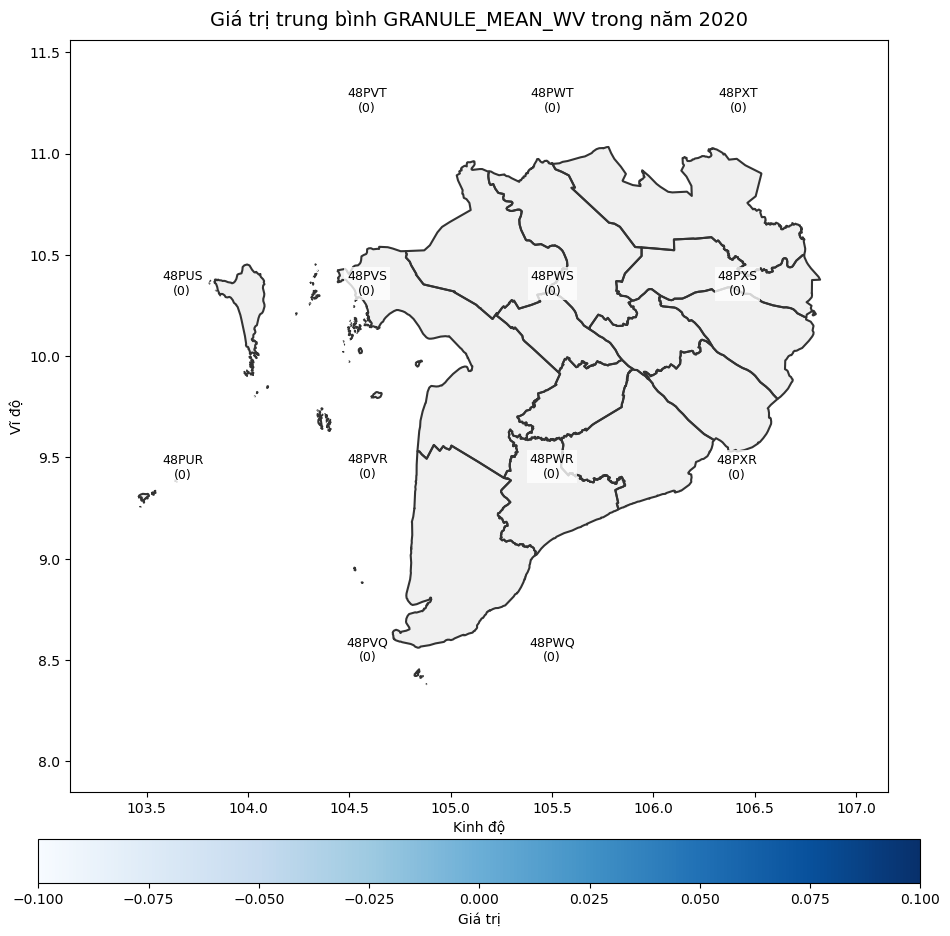

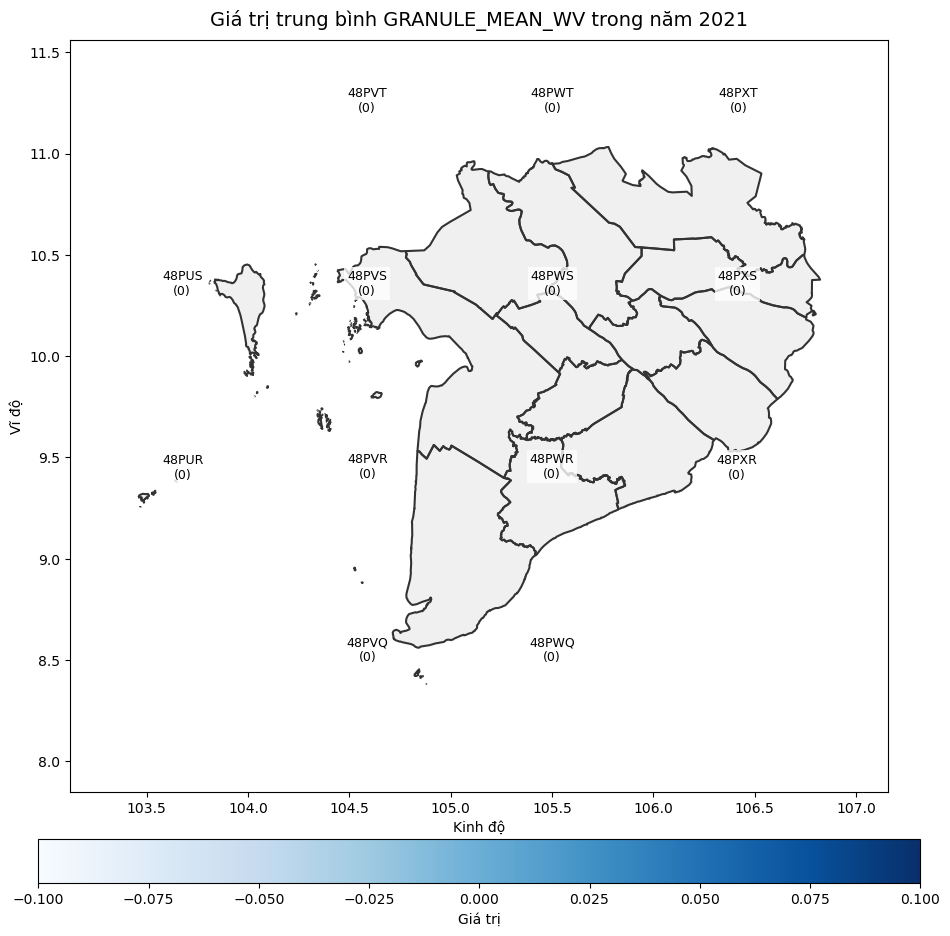

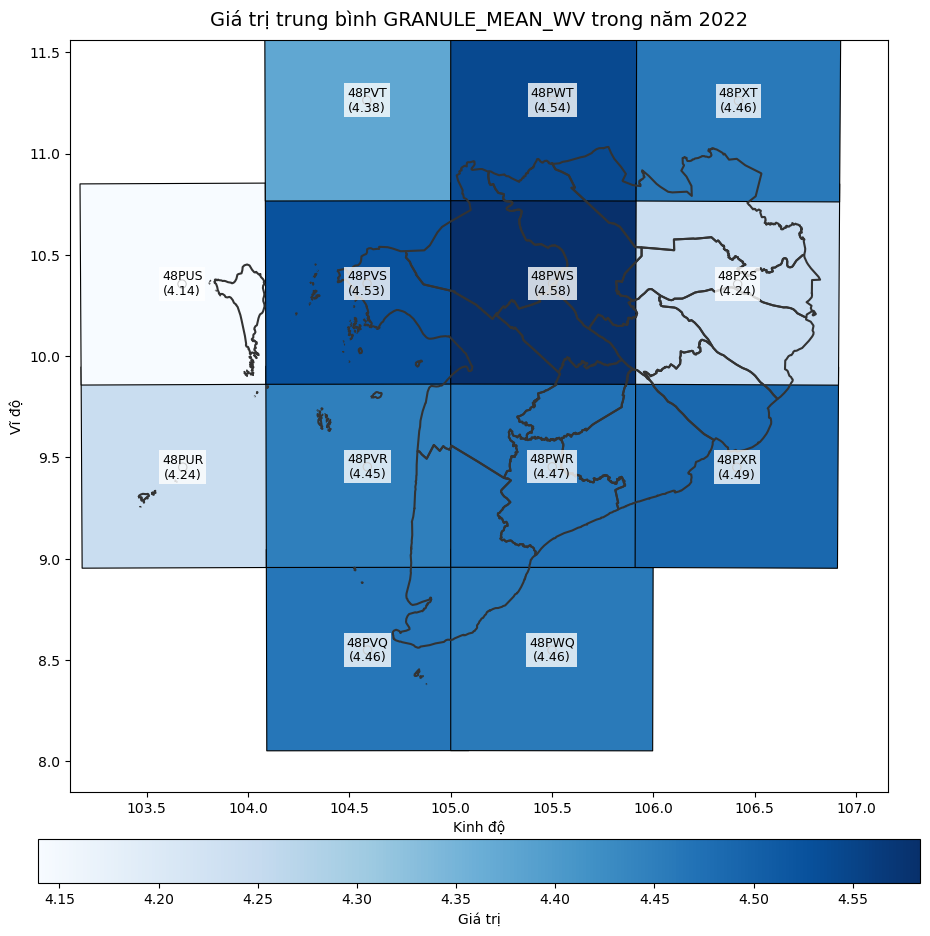

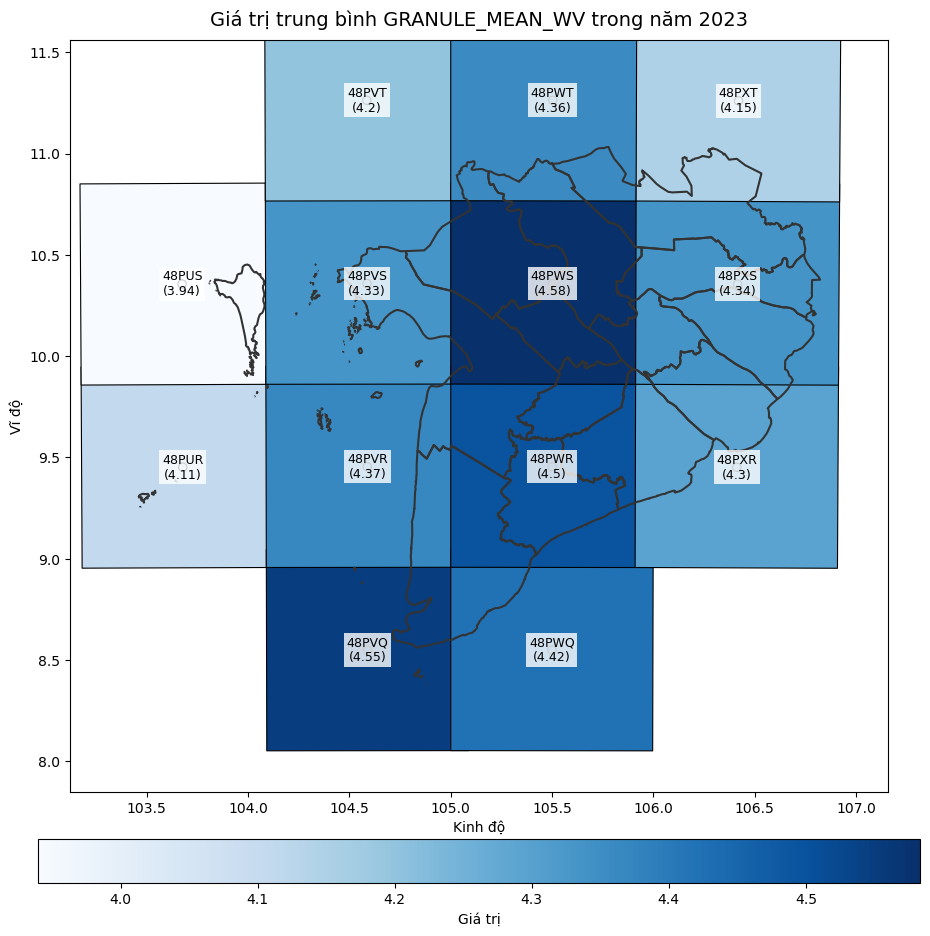

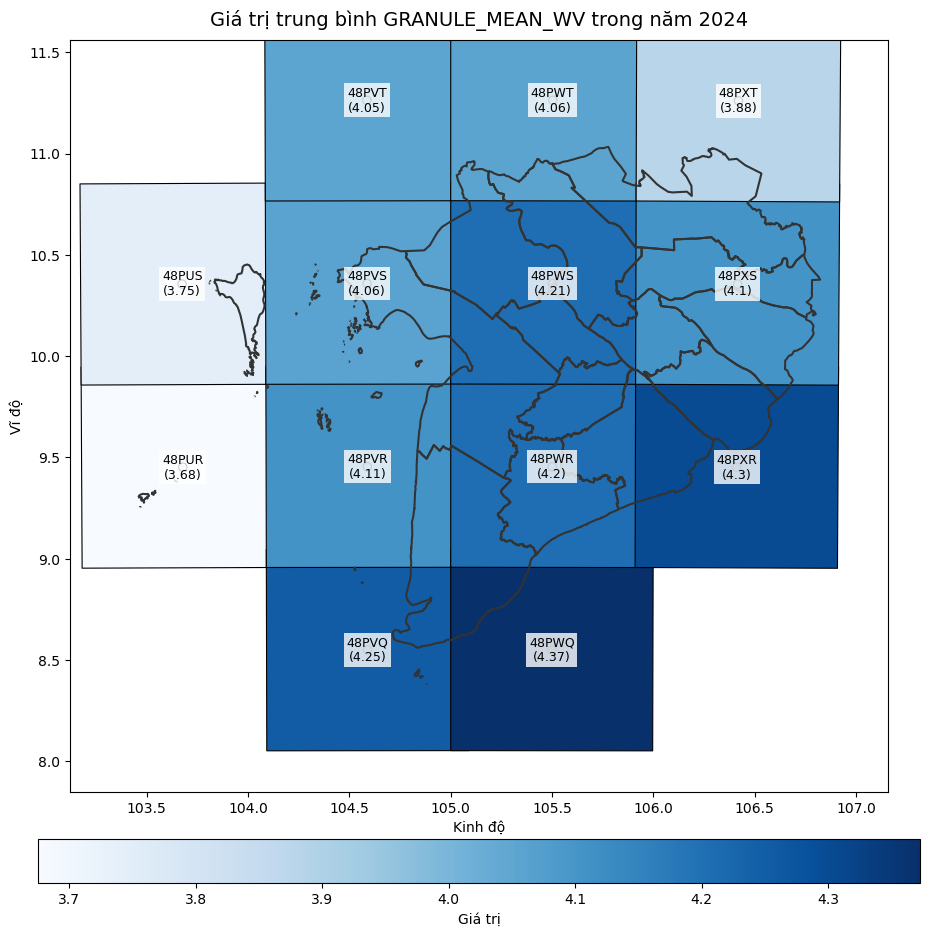

In [9]:
file = 'mean_GRANULE_MEAN_WV.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

### OZONE_VALUE

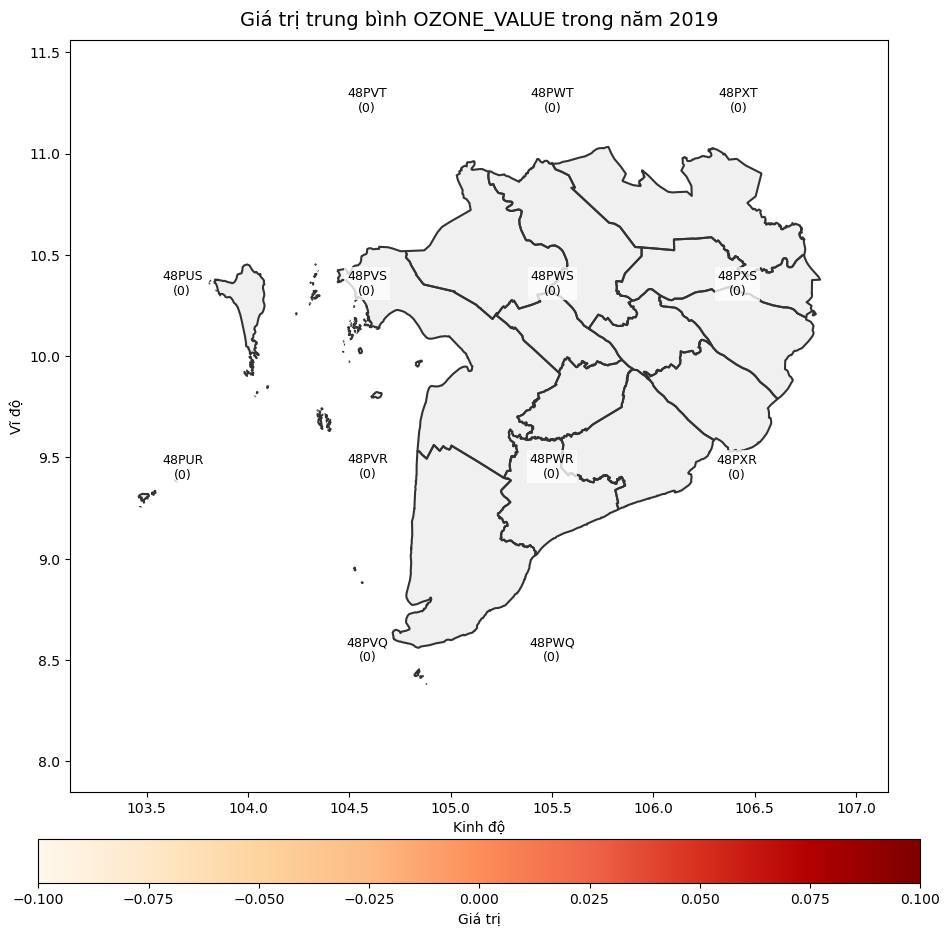

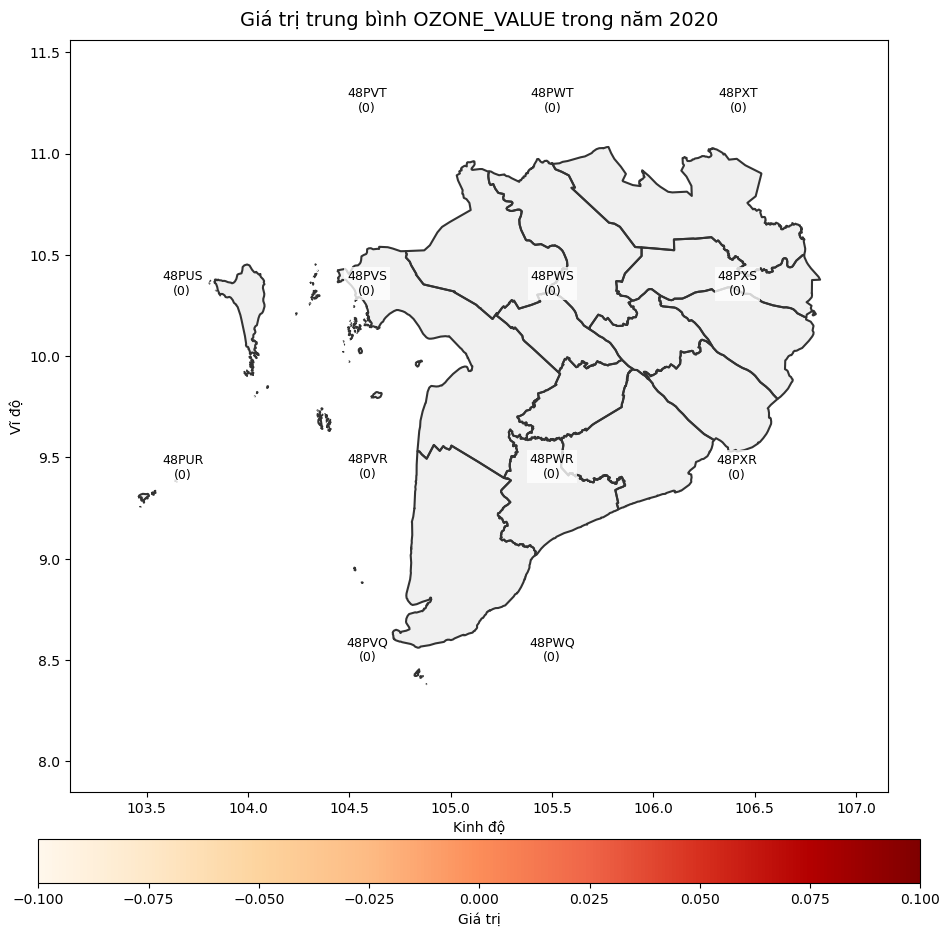

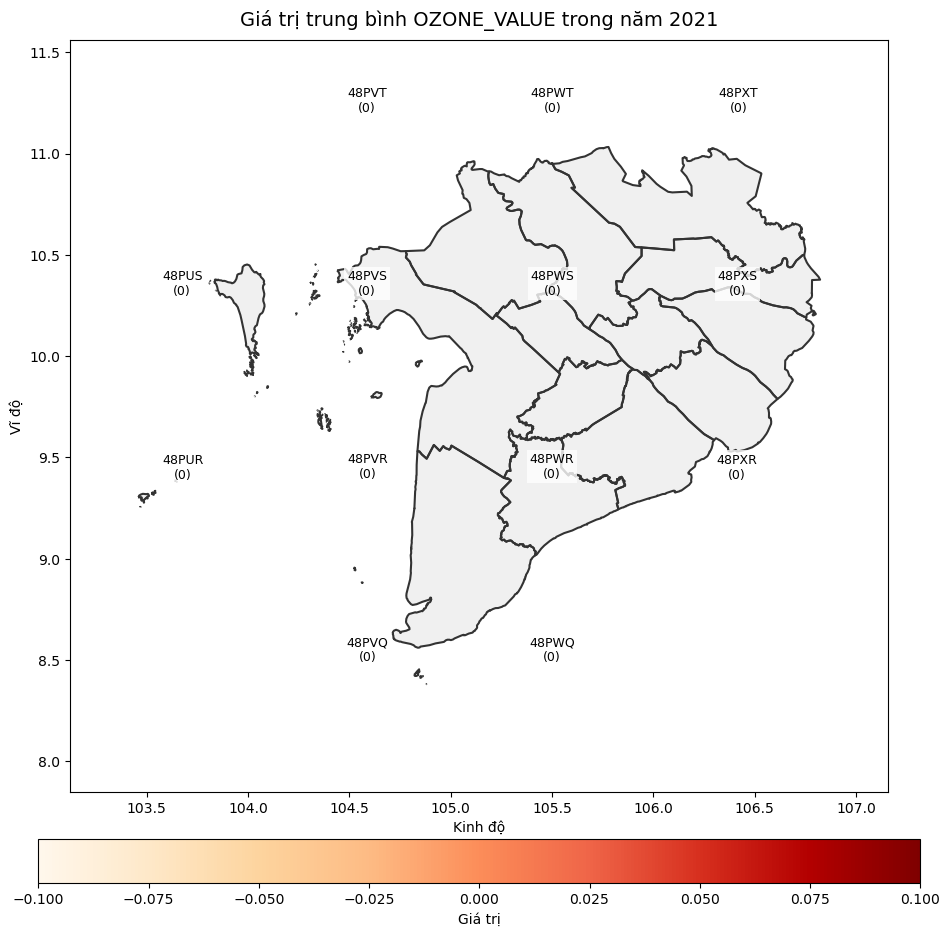

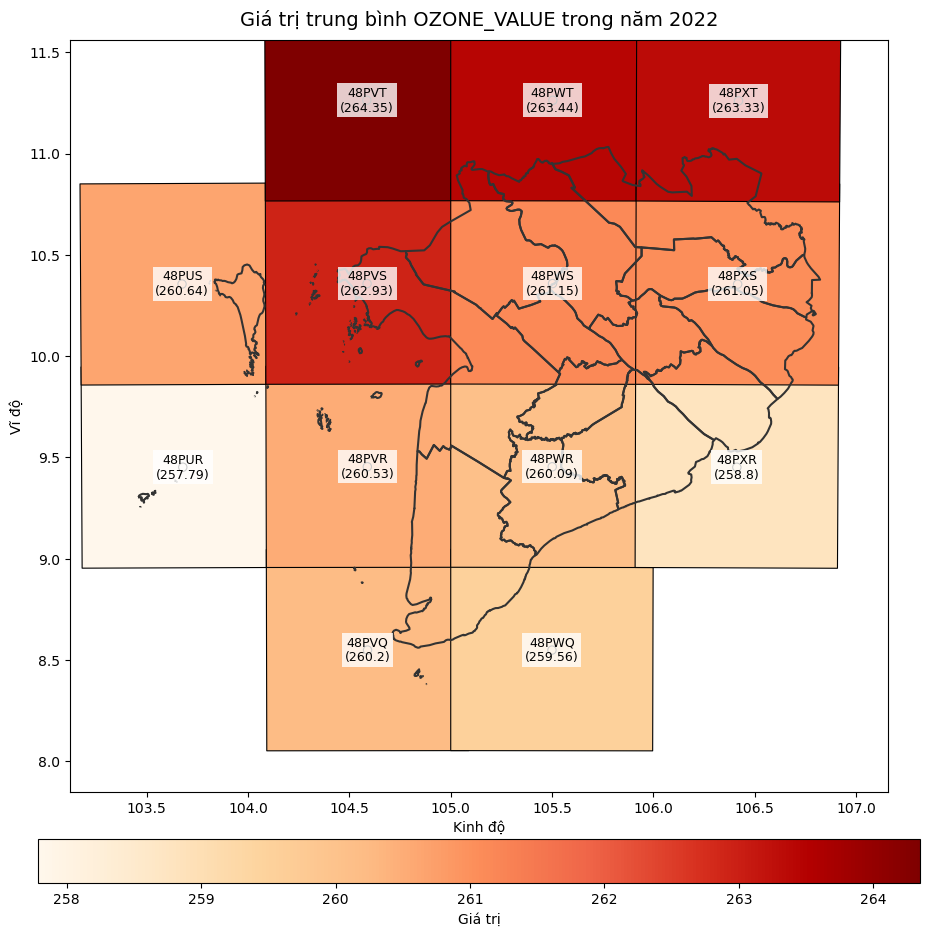

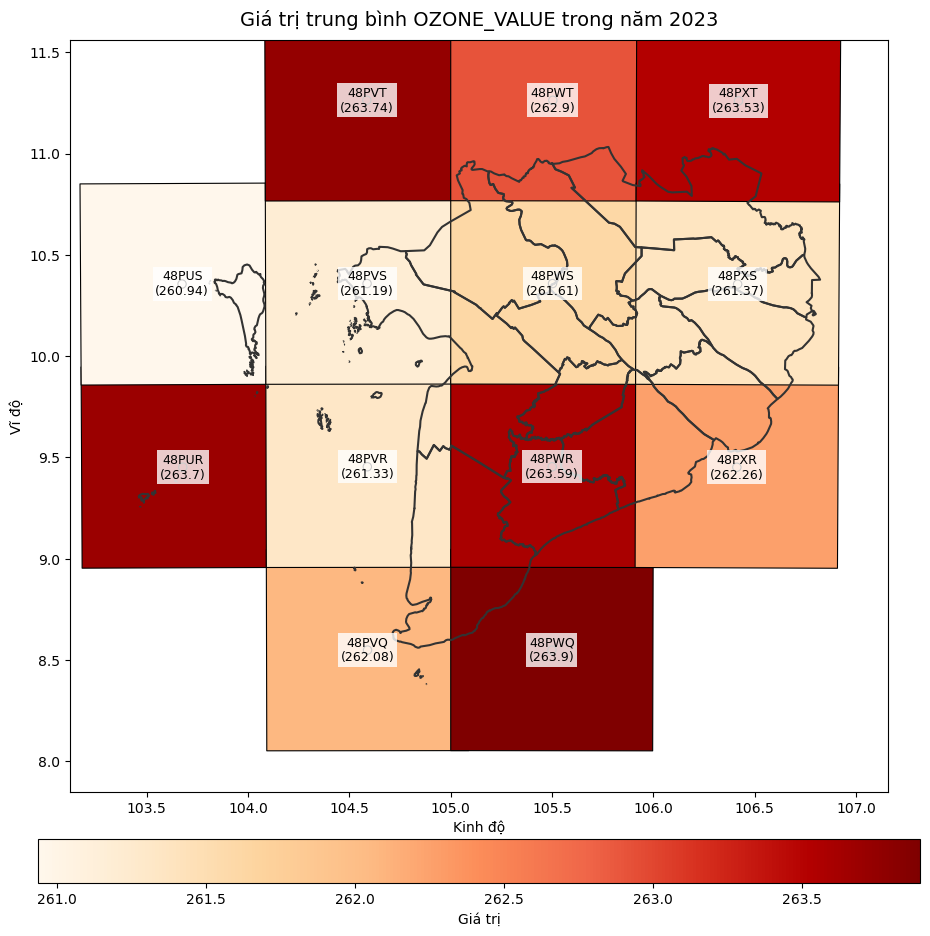

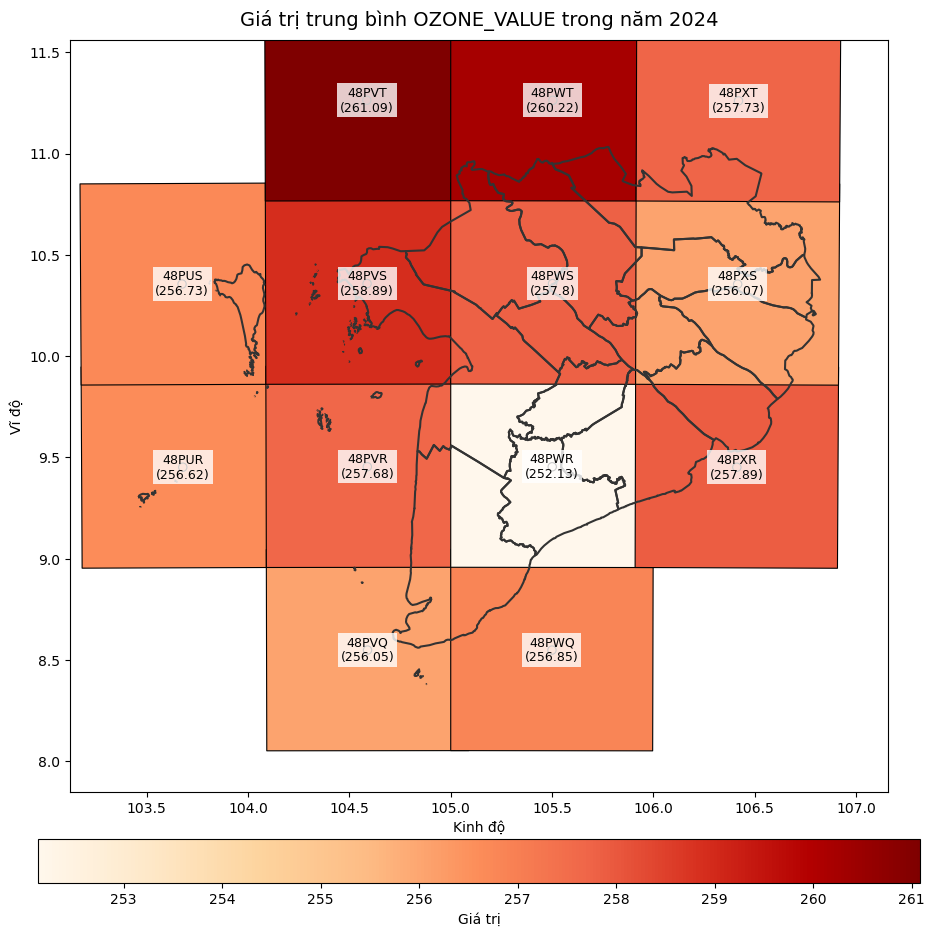

In [10]:
file = 'mean_OZONE_VALUE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run()

### THIN_CIRRUS_PERCENTAGE

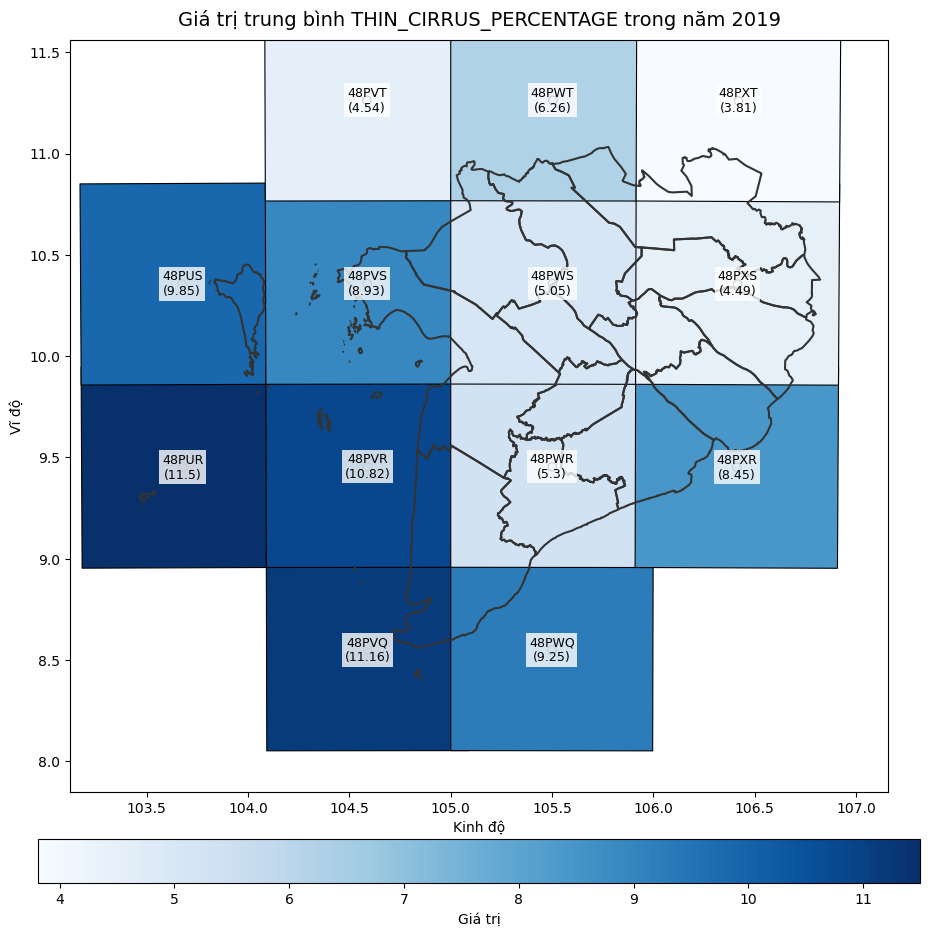

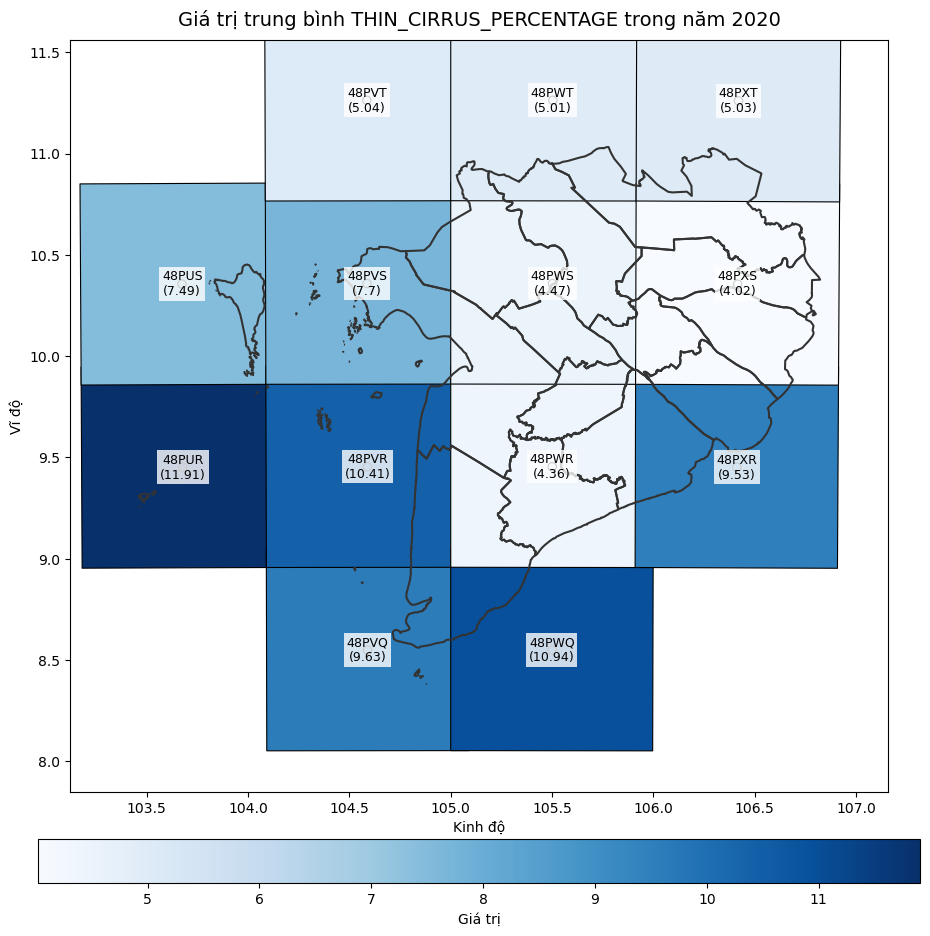

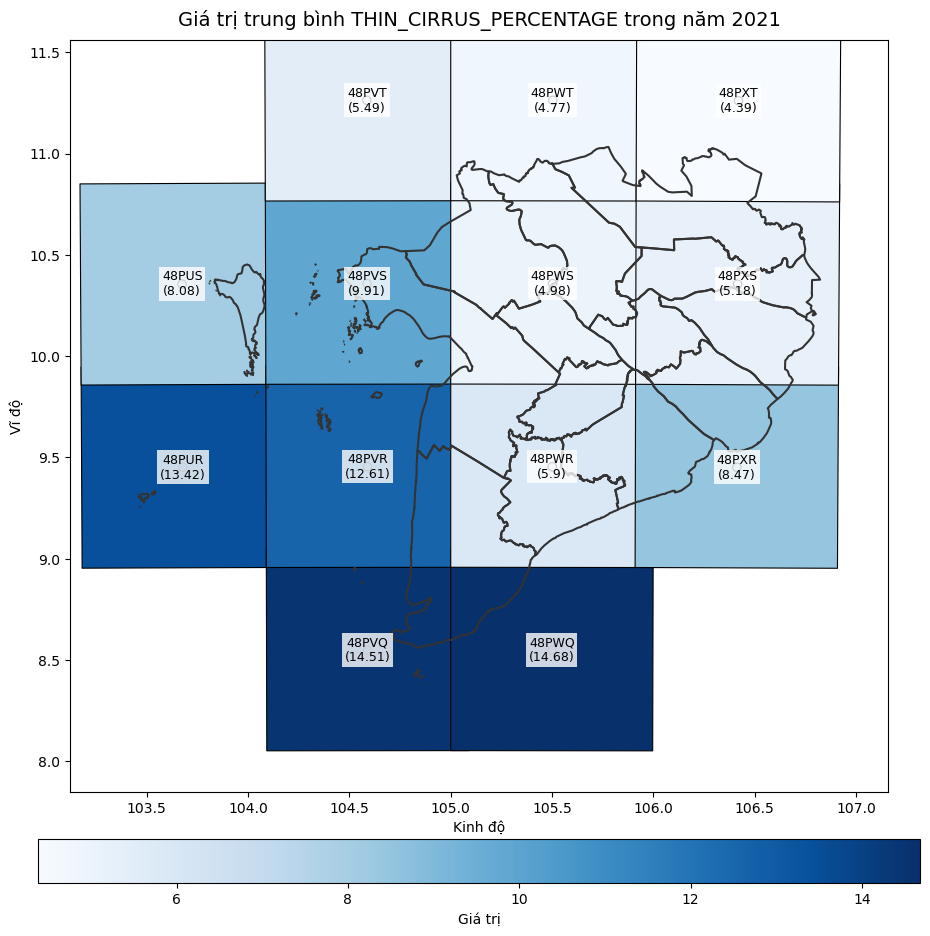

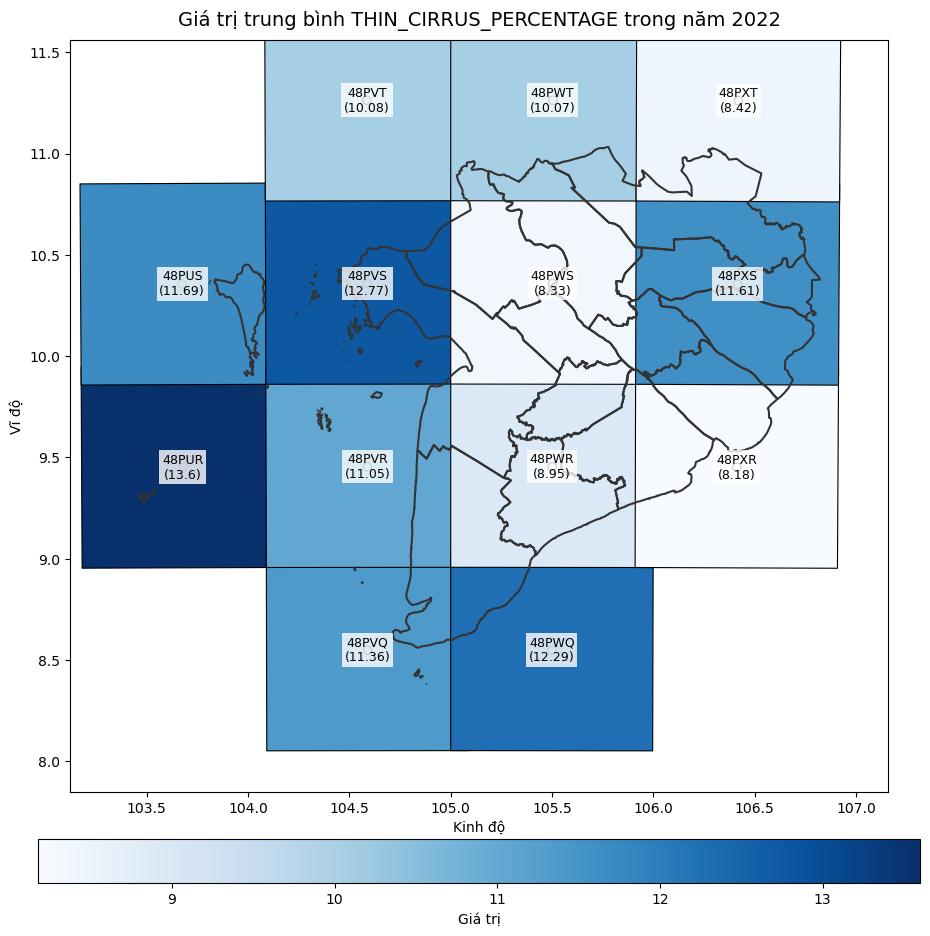

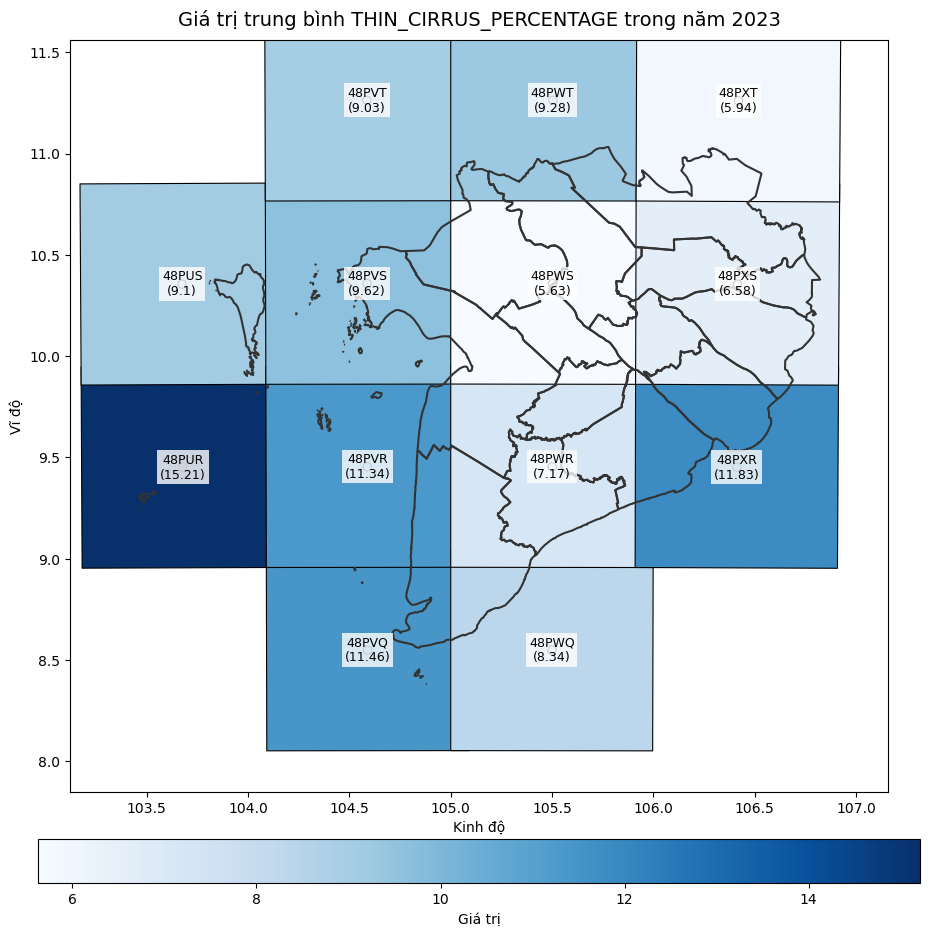

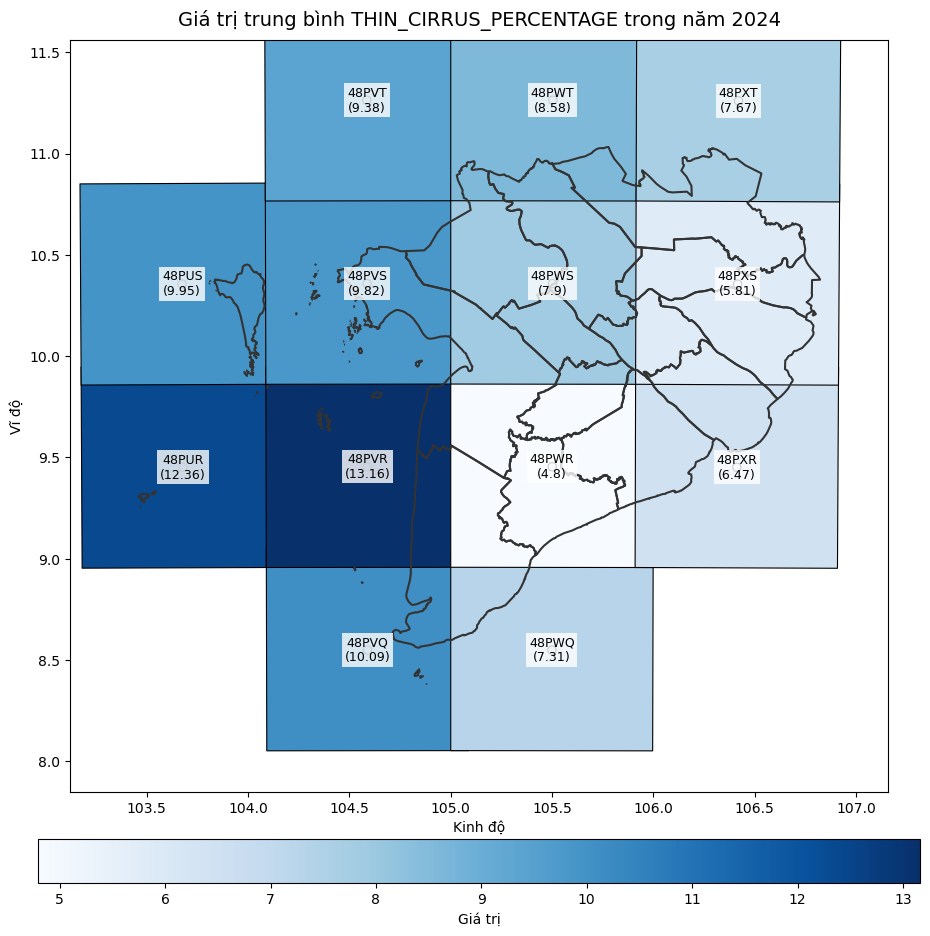

In [11]:
file = 'mean_THIN_CIRRUS_PERCENTAGE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

### VEGETATION_PERCENTAGE

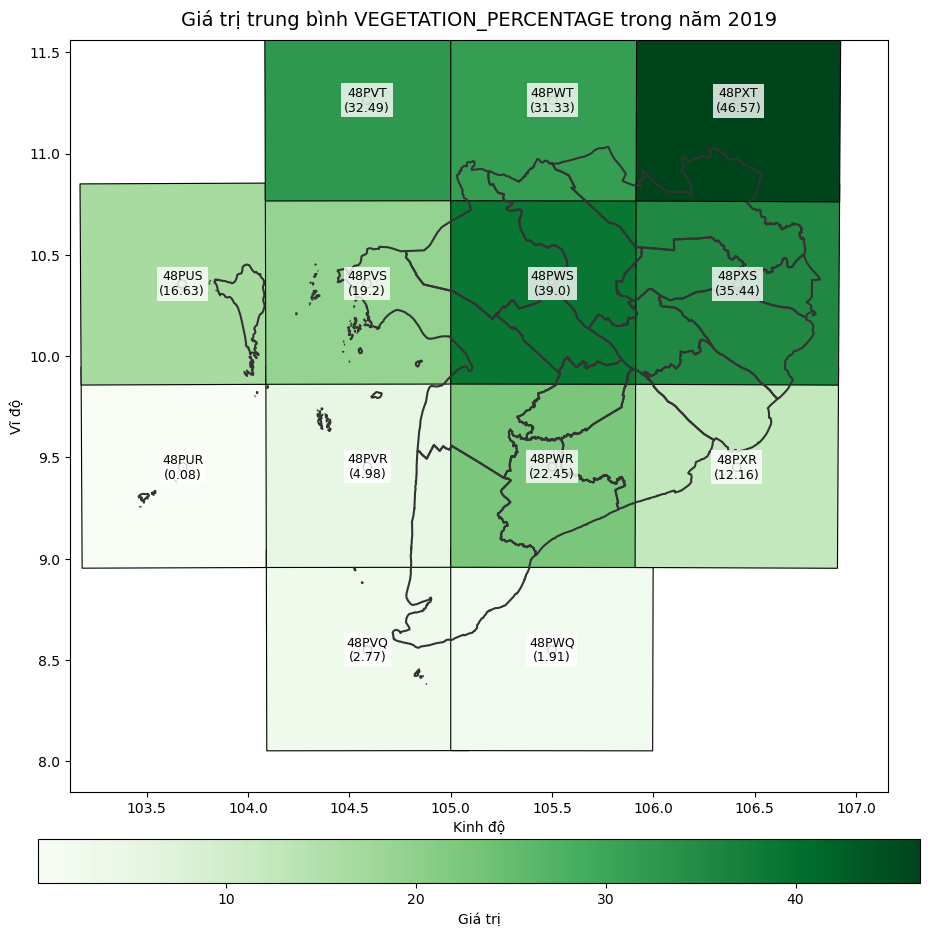

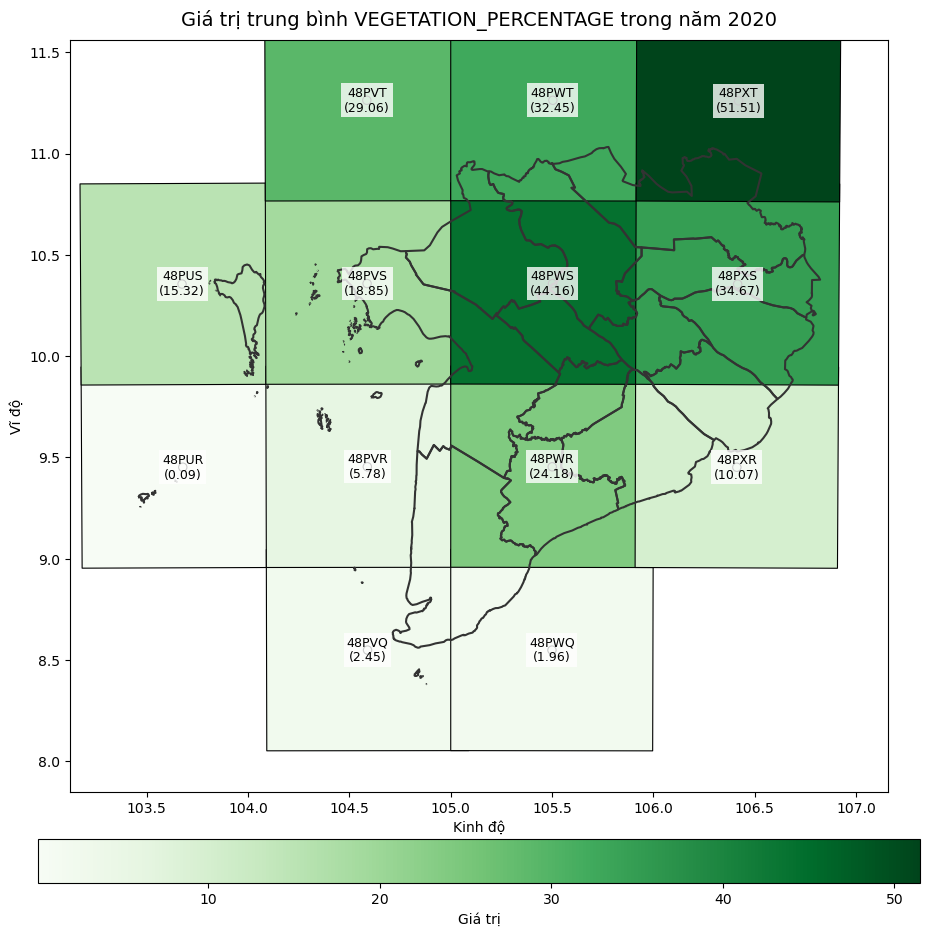

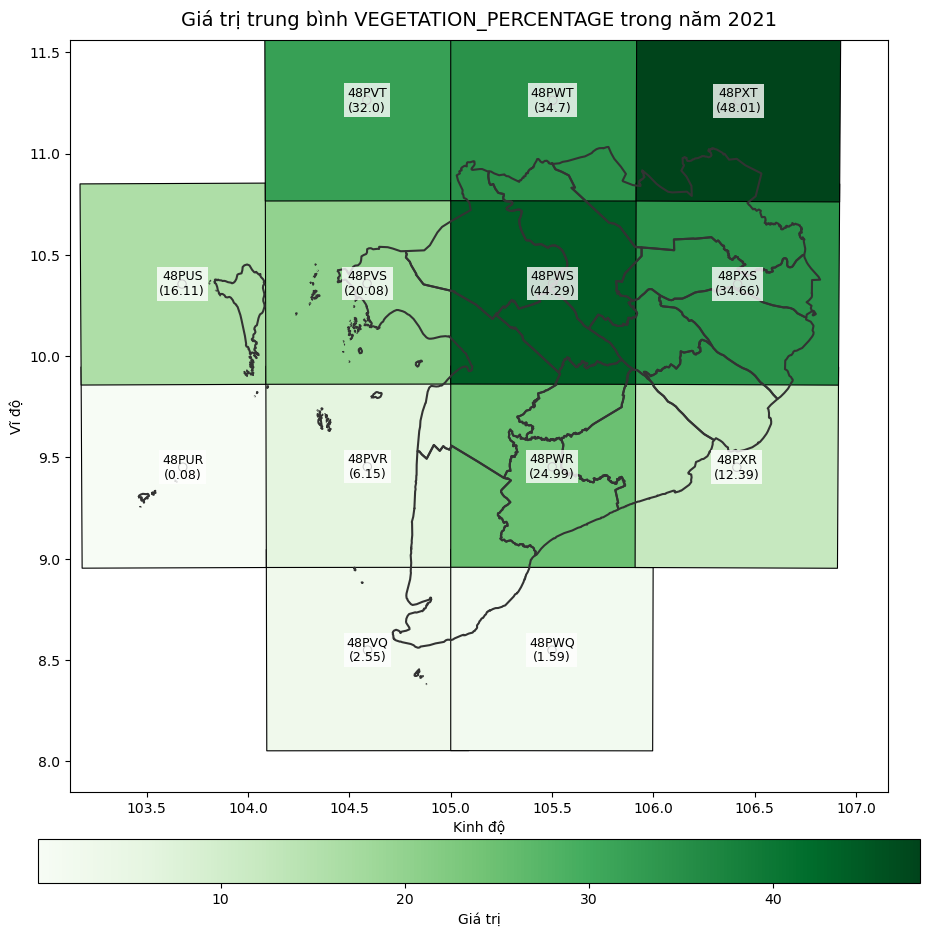

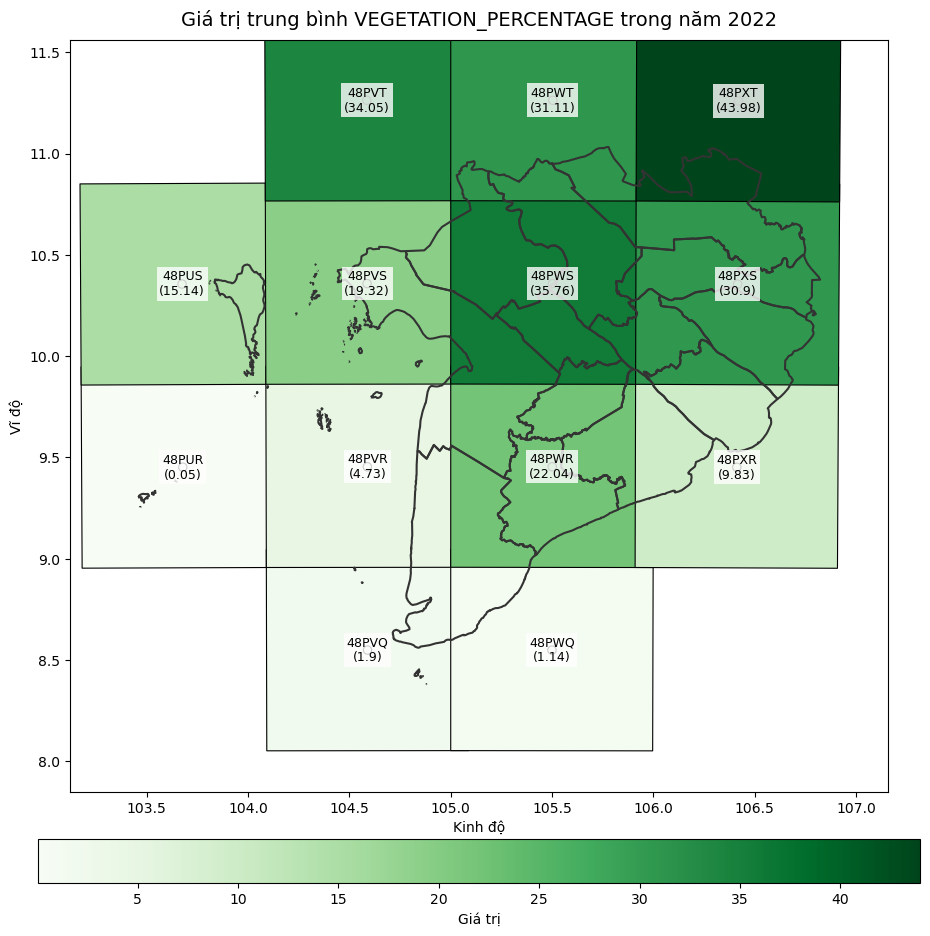

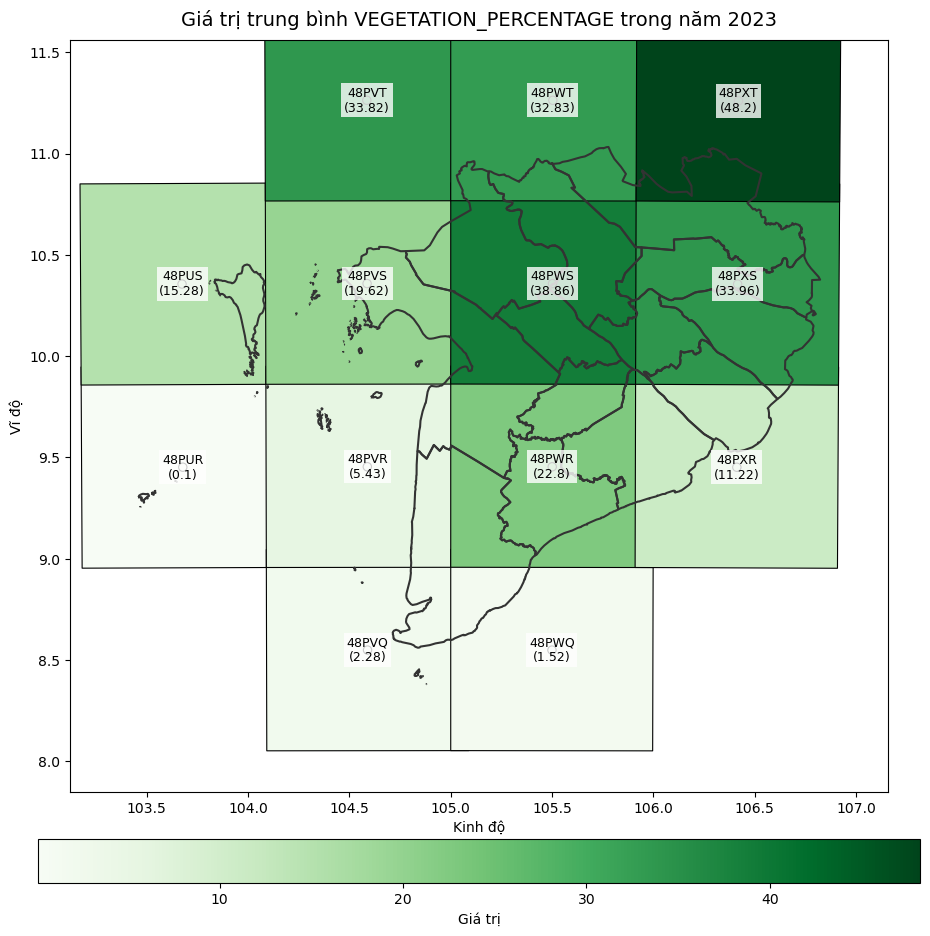

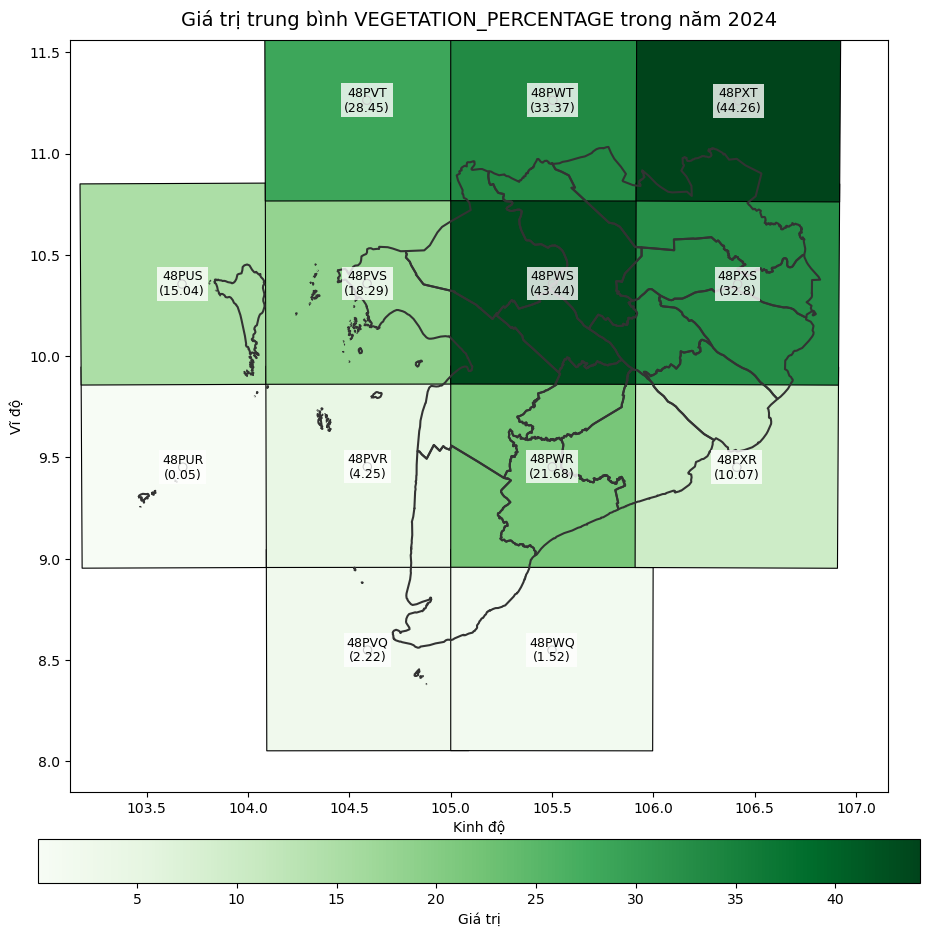

In [12]:
file = 'mean_VEGETATION_PERCENTAGE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Greens')

### WATER_PERCENTAGE

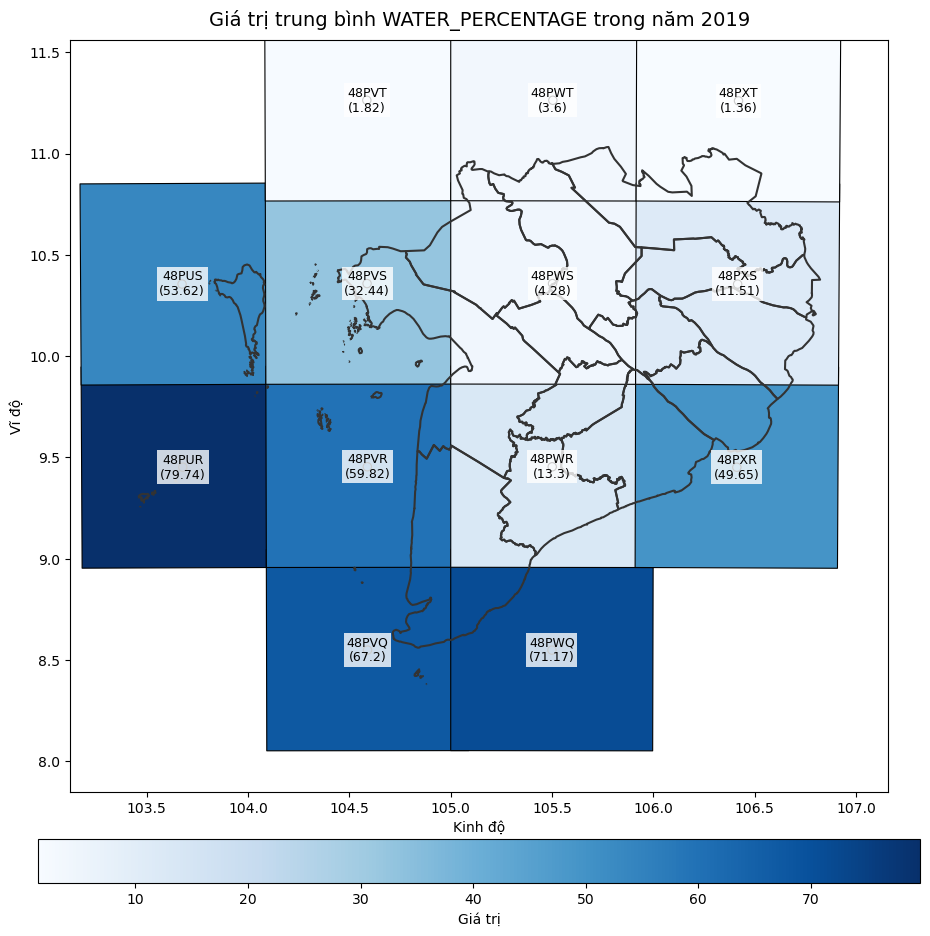

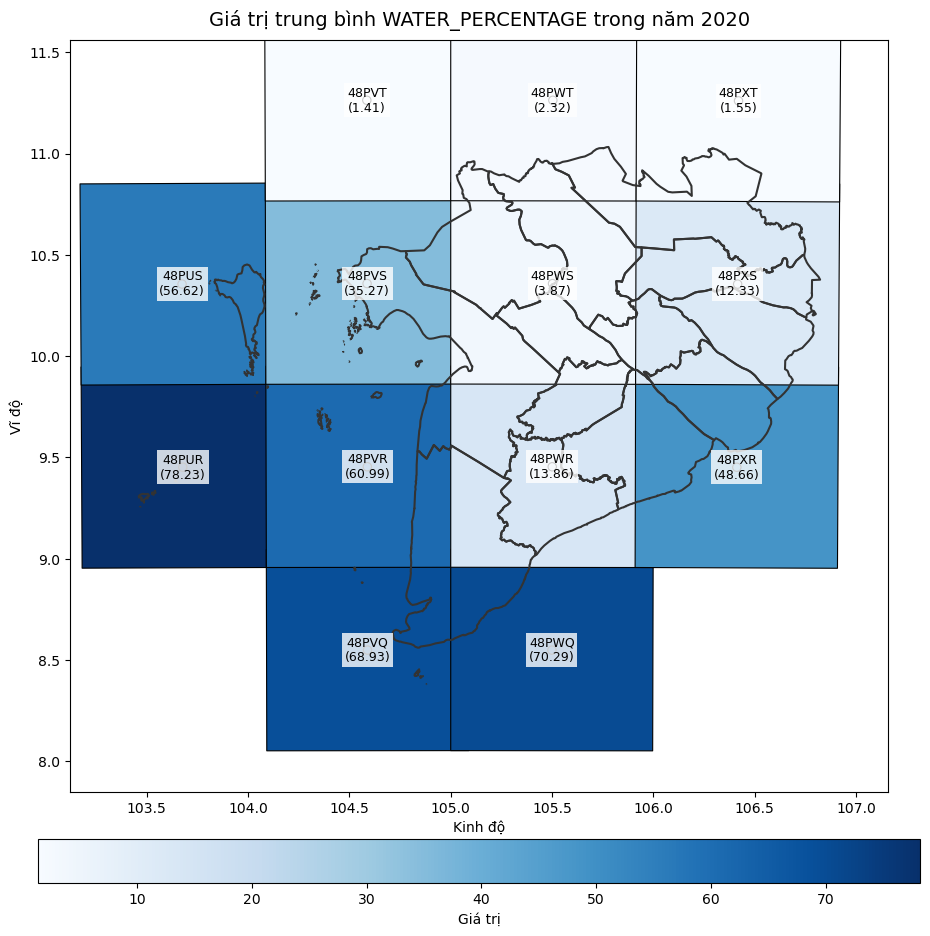

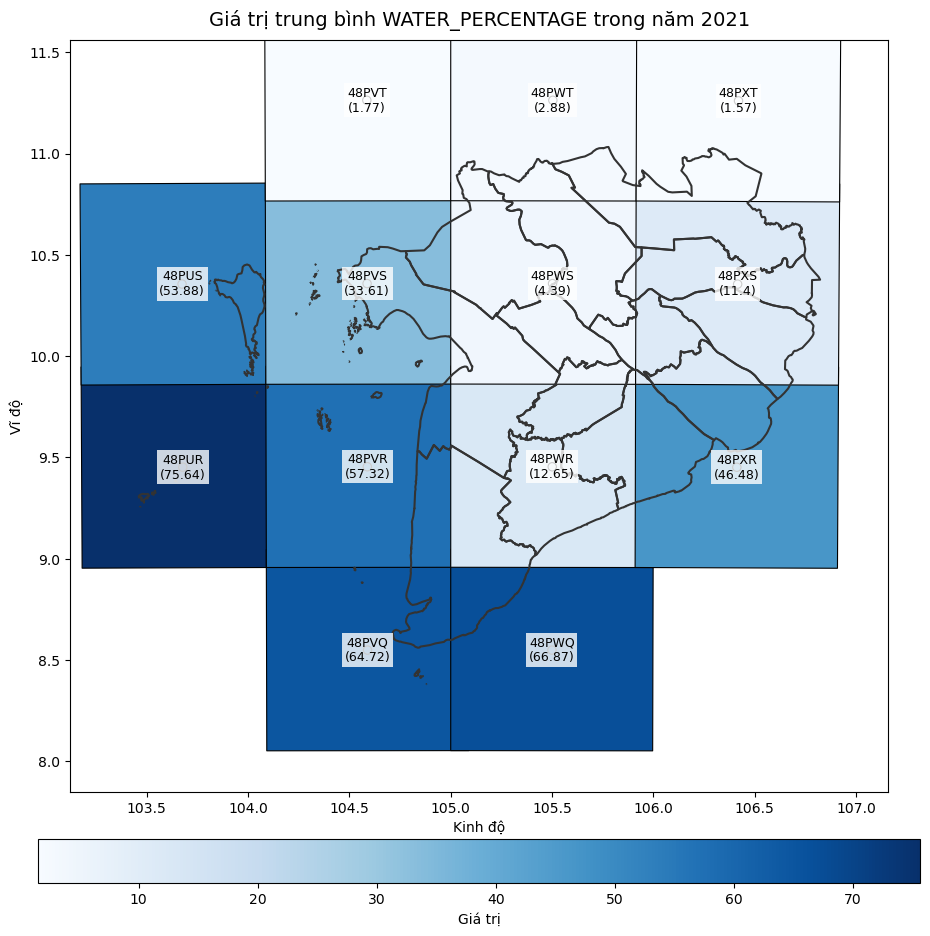

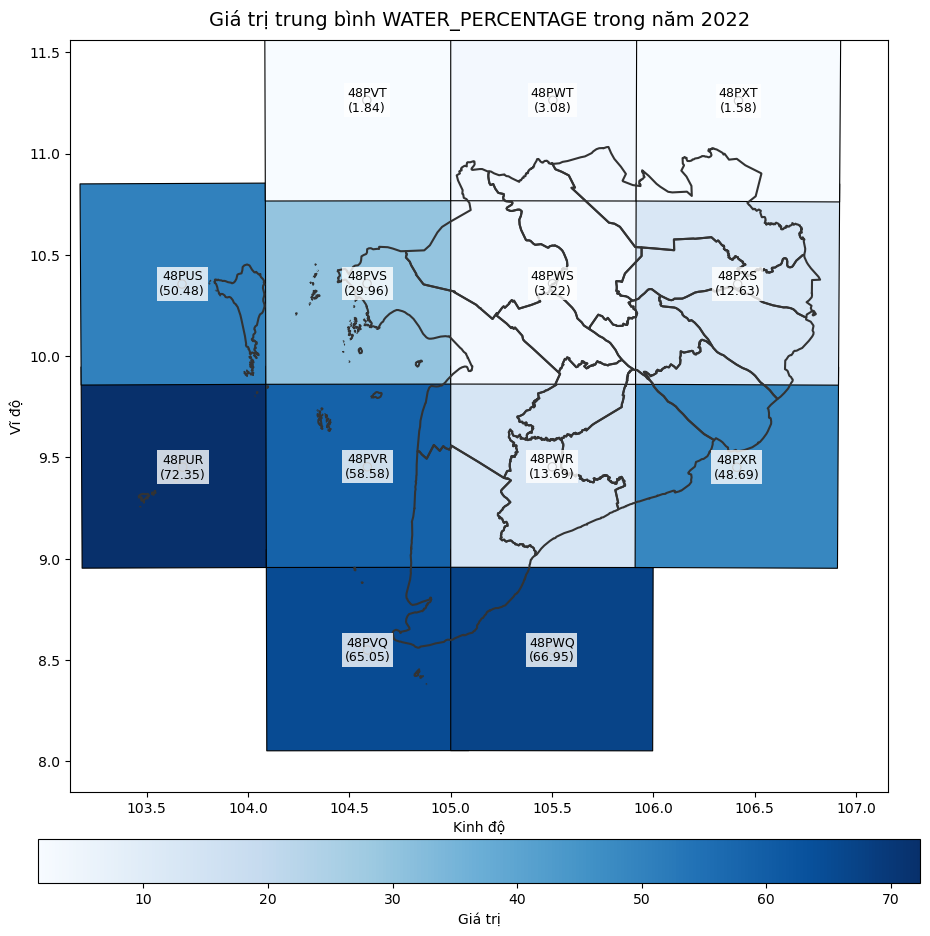

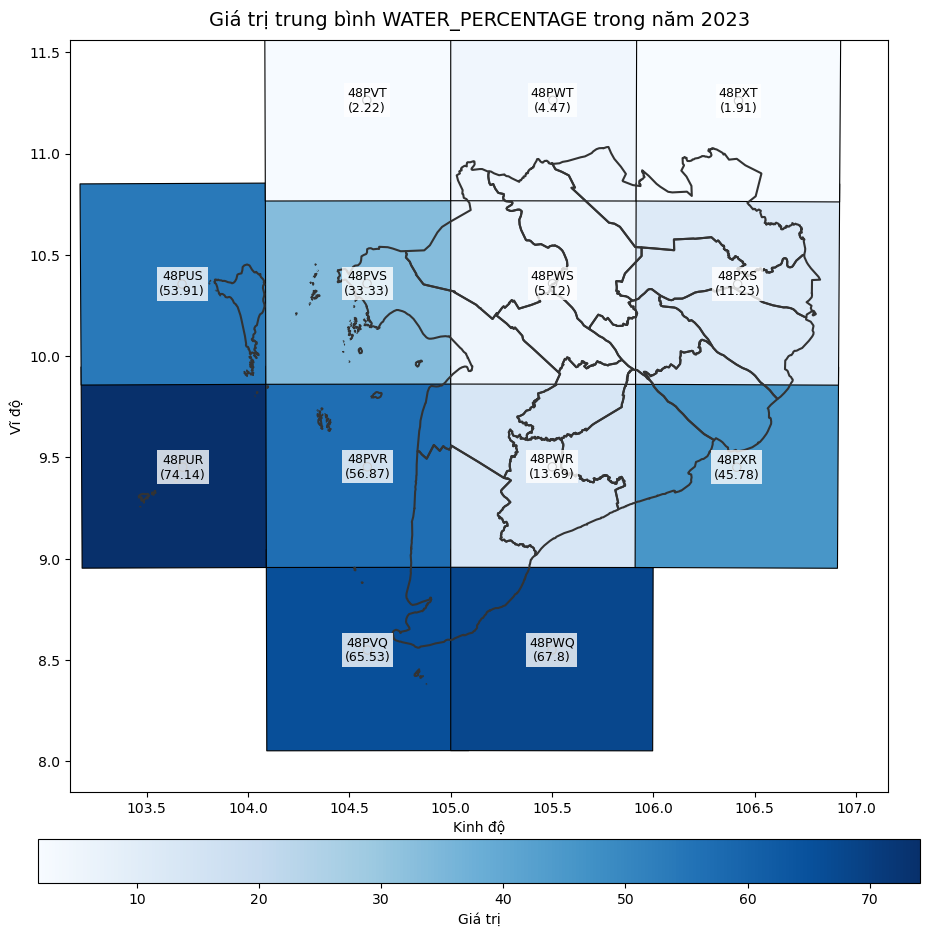

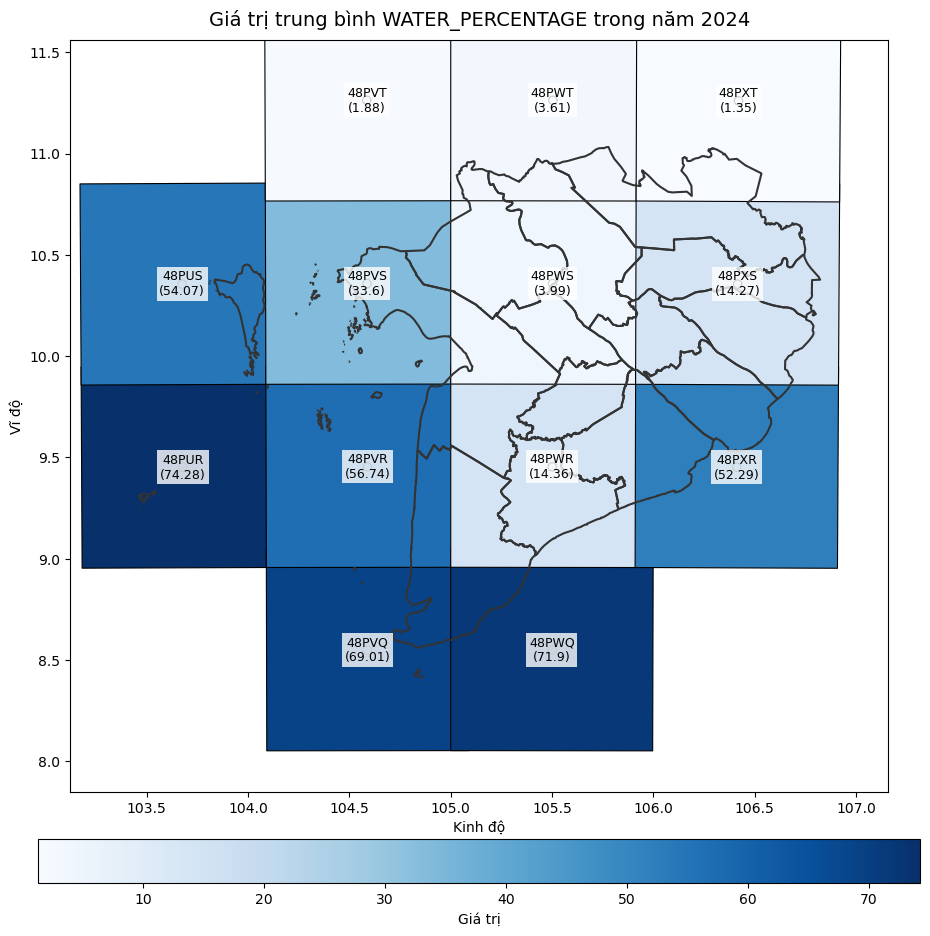

In [13]:
file = 'mean_WATER_PERCENTAGE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

### SNOW_ICE_PERCENTAGE

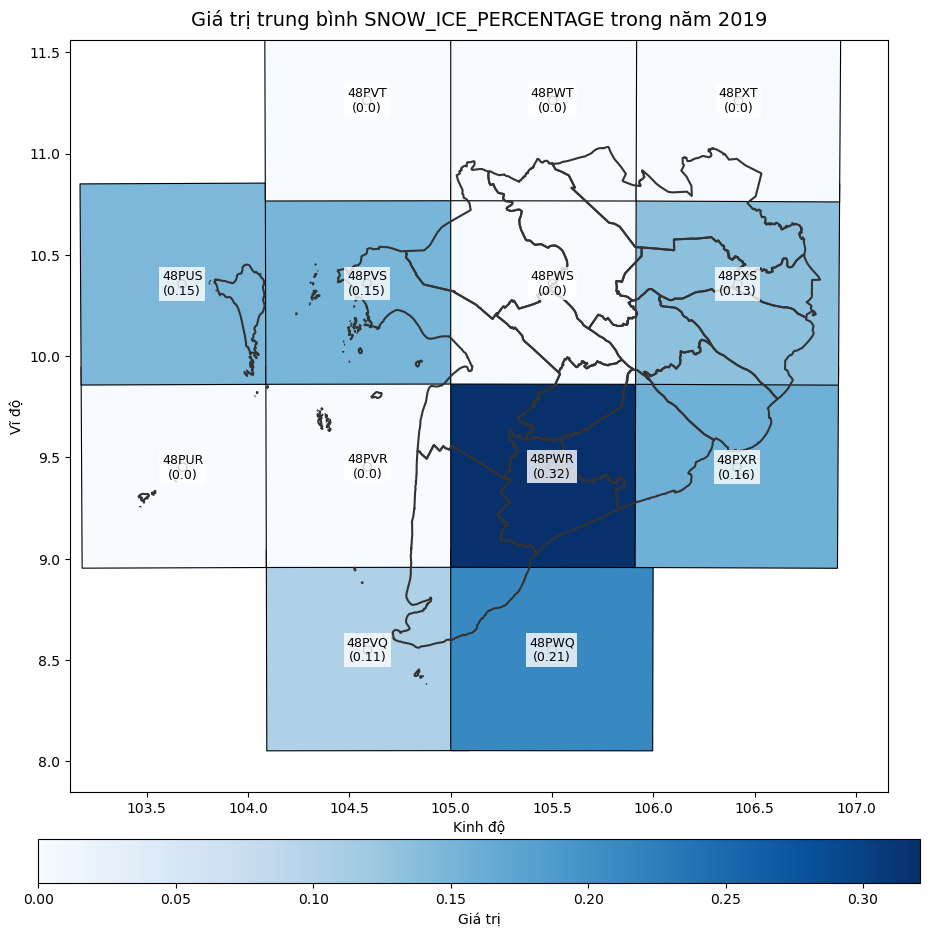

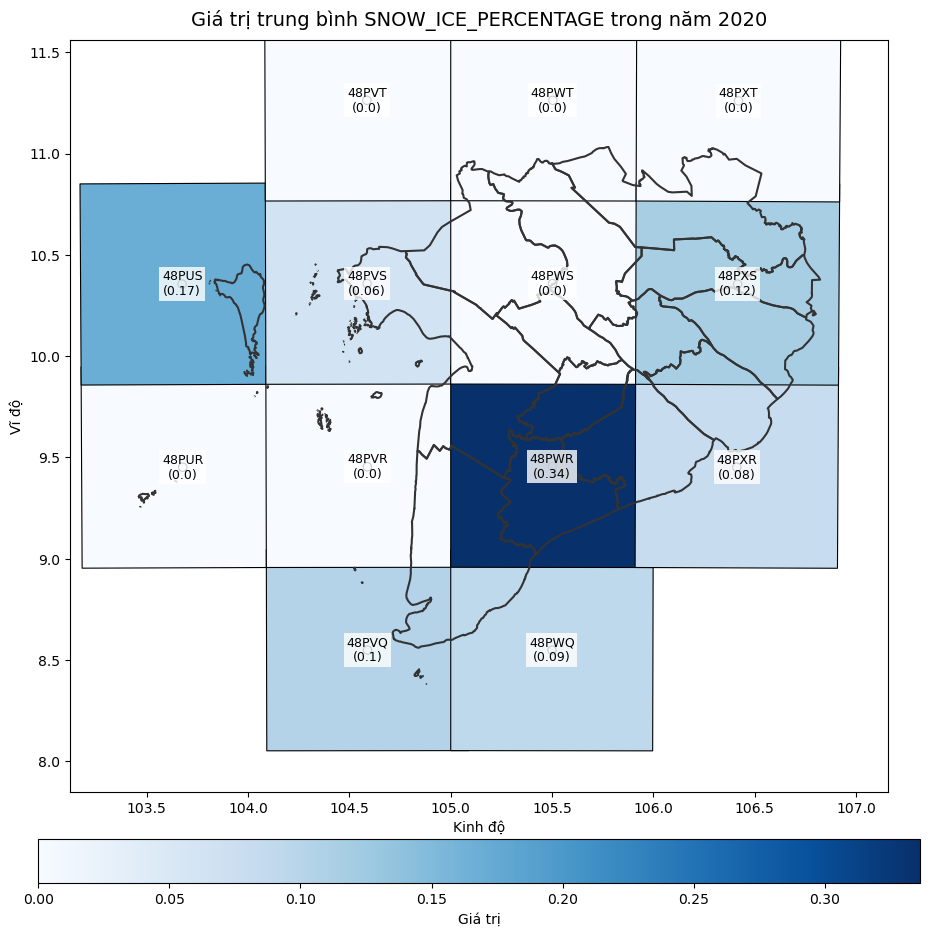

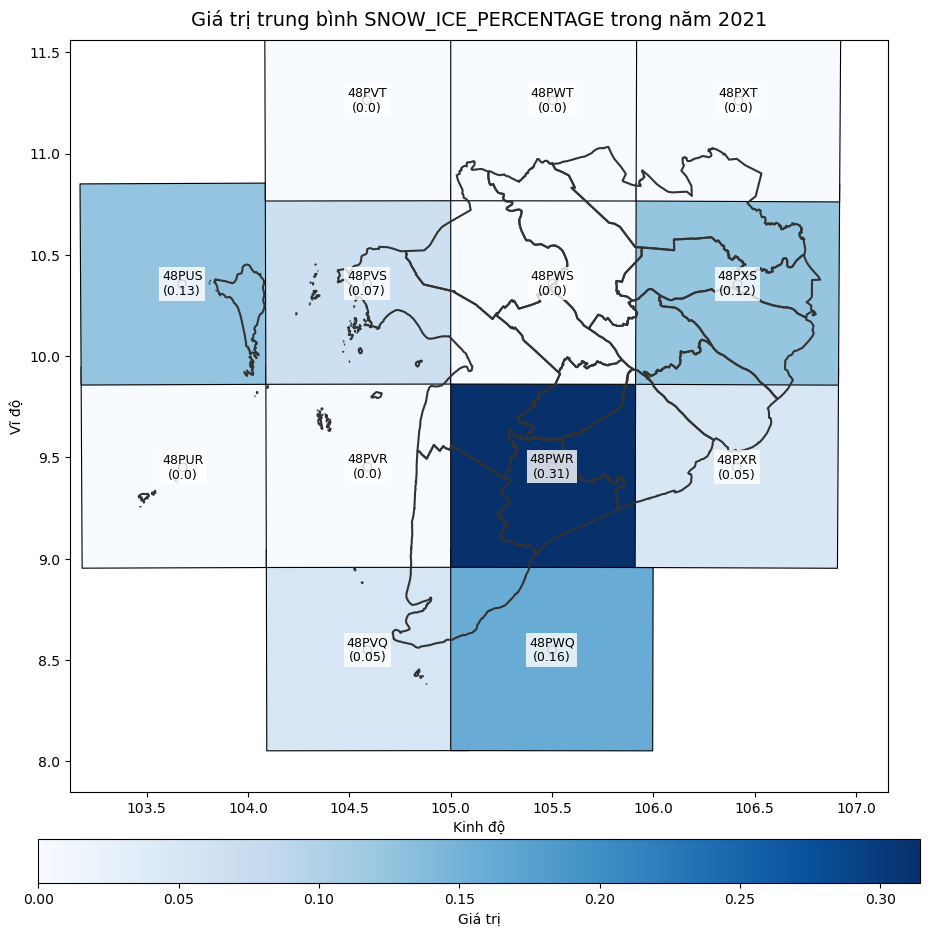

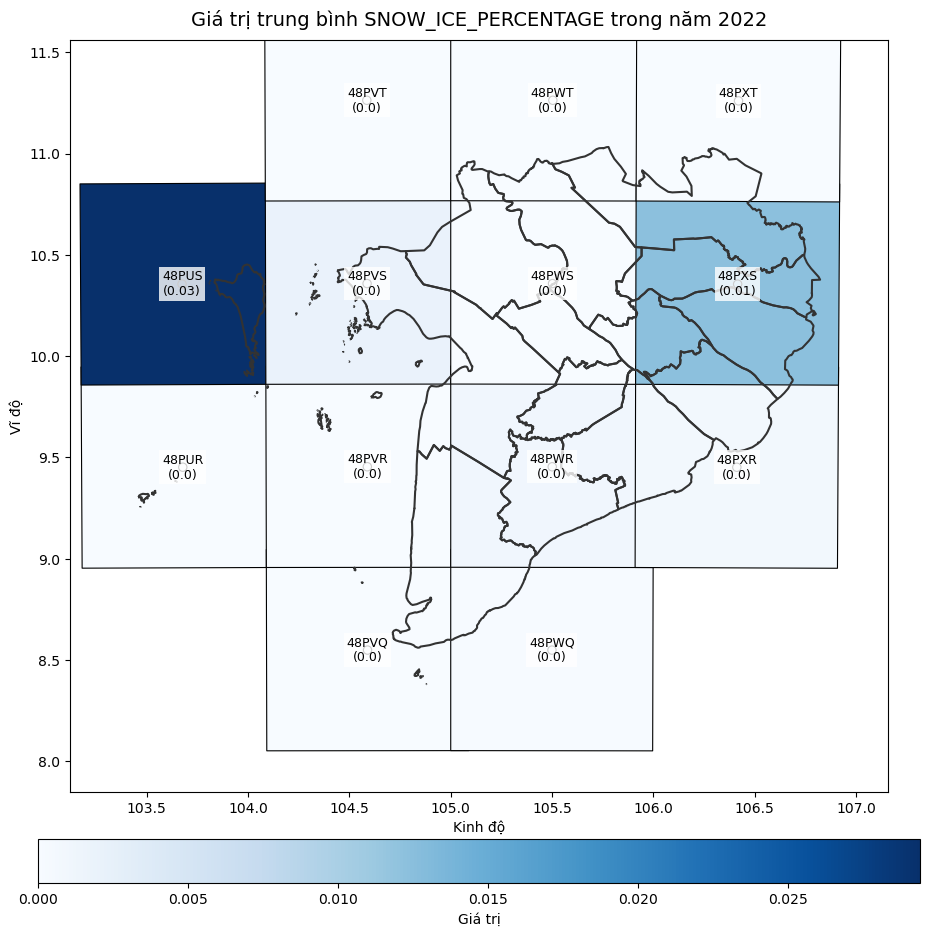

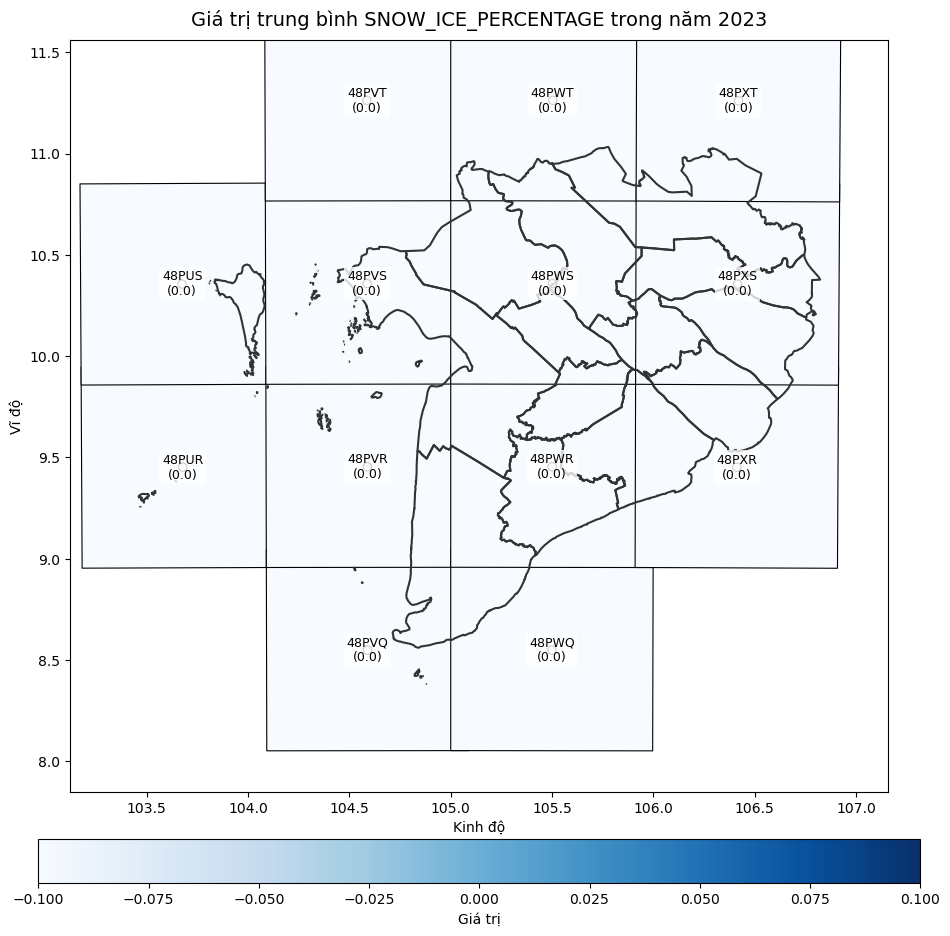

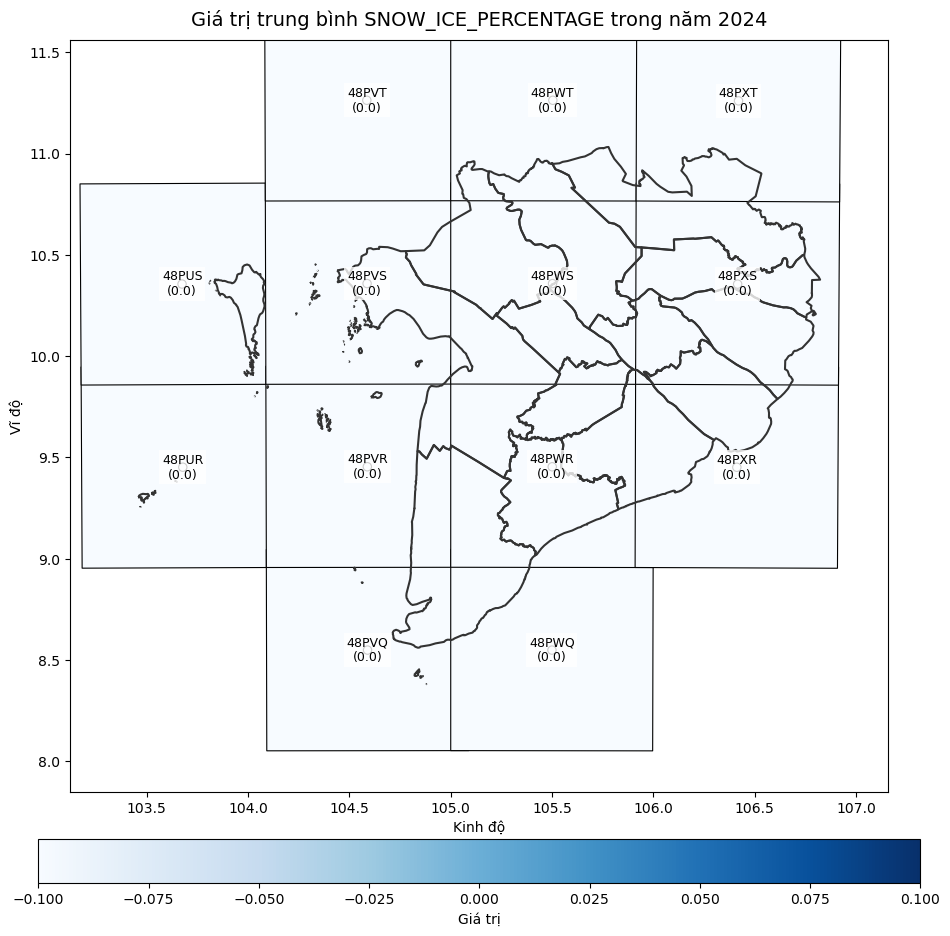

In [14]:
file = 'mean_SNOW_ICE_PERCENTAGE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run('Blues')

ĐBSCL không có vùng băng tuyết, chắc do hệ thống tính nhầm qua Cloud :)))

### MEAN_SOLAR_ZENITH_ANGLE

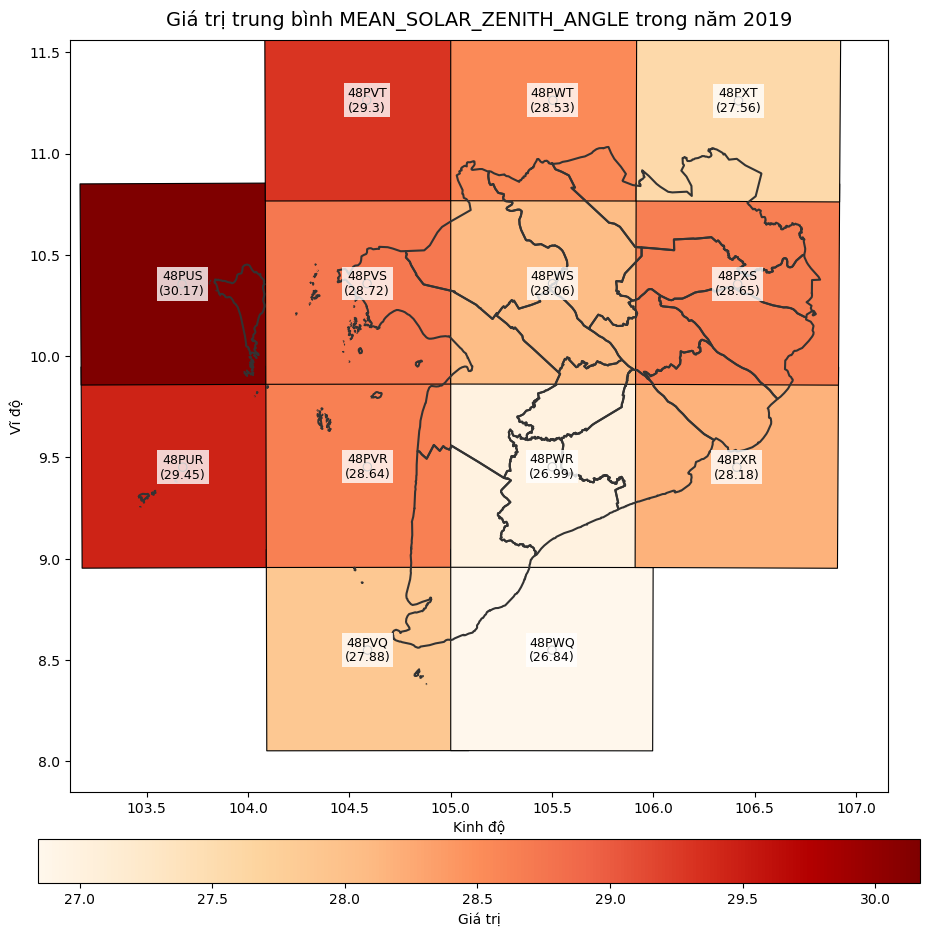

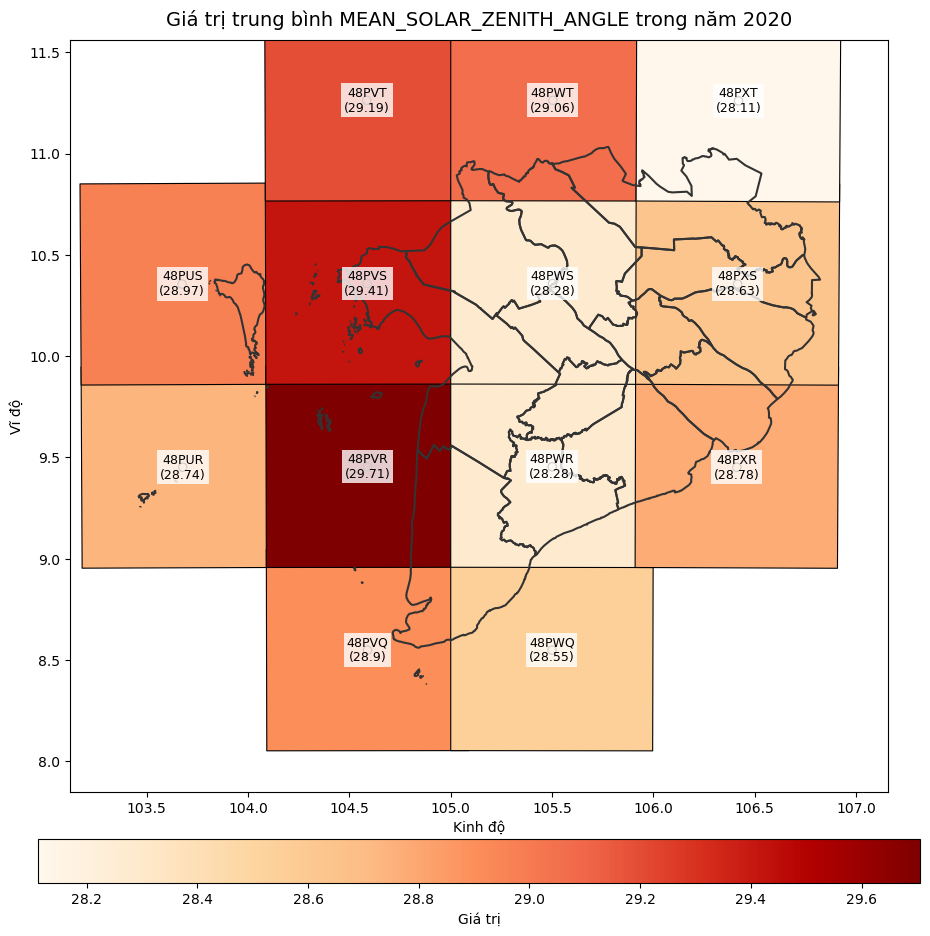

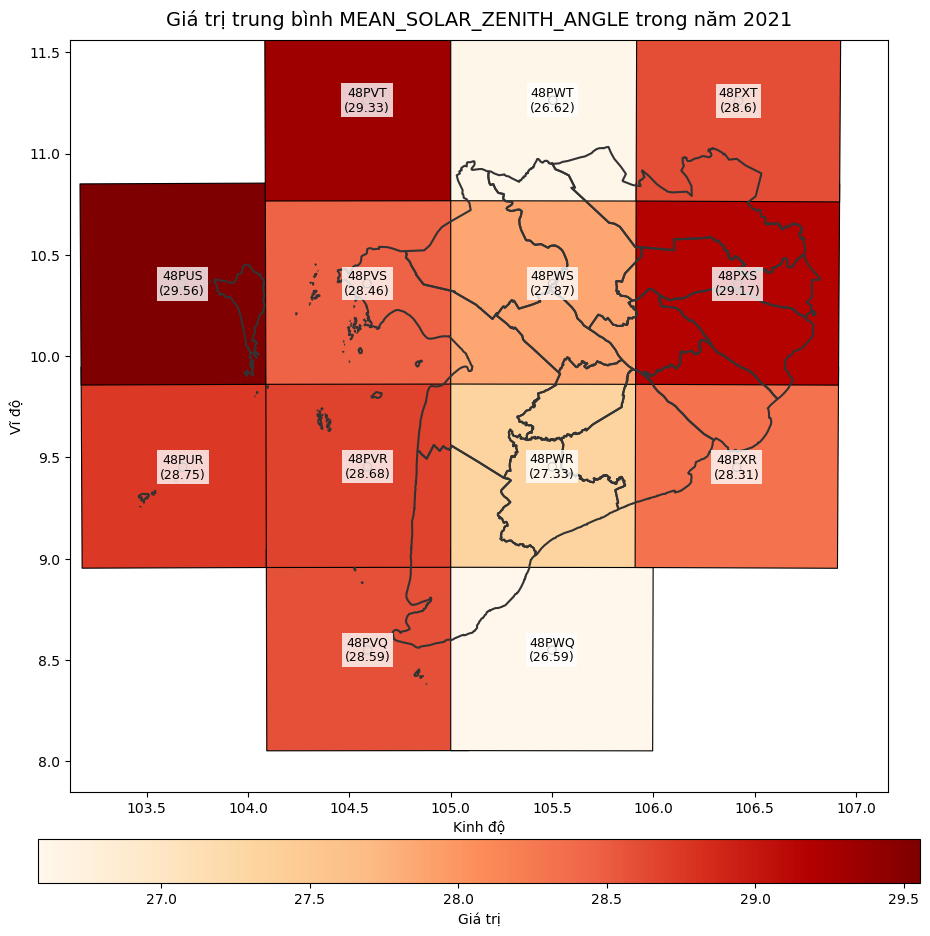

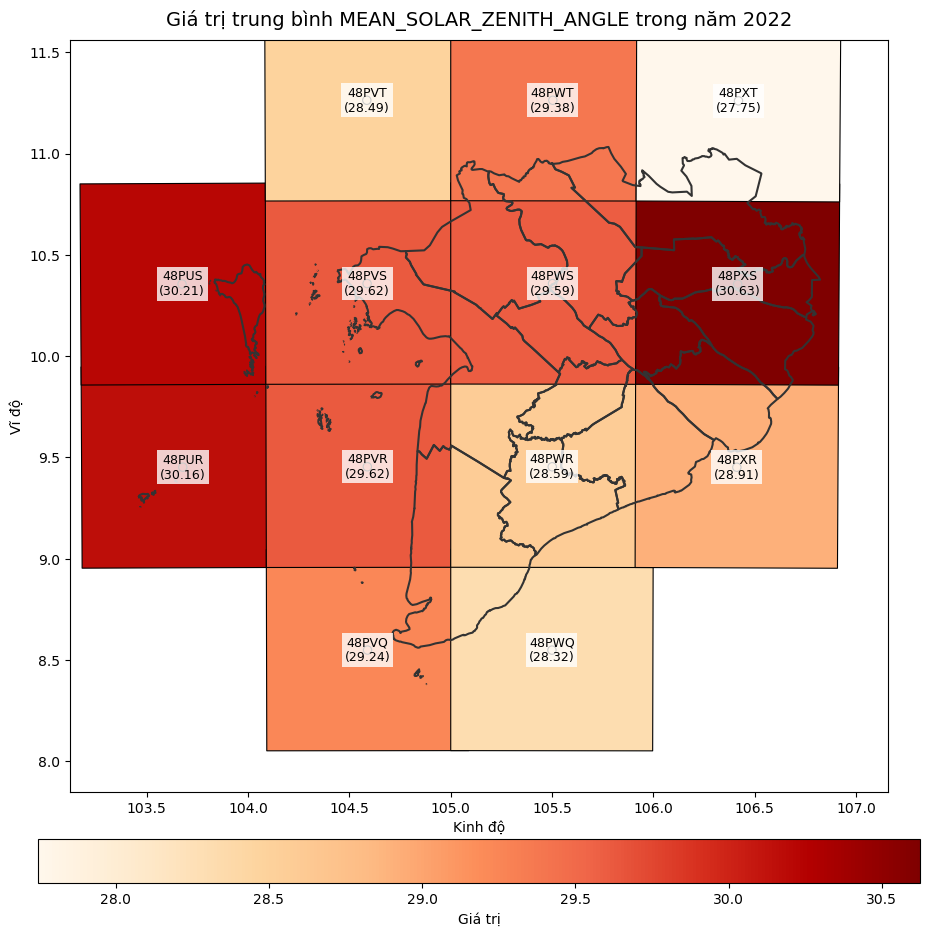

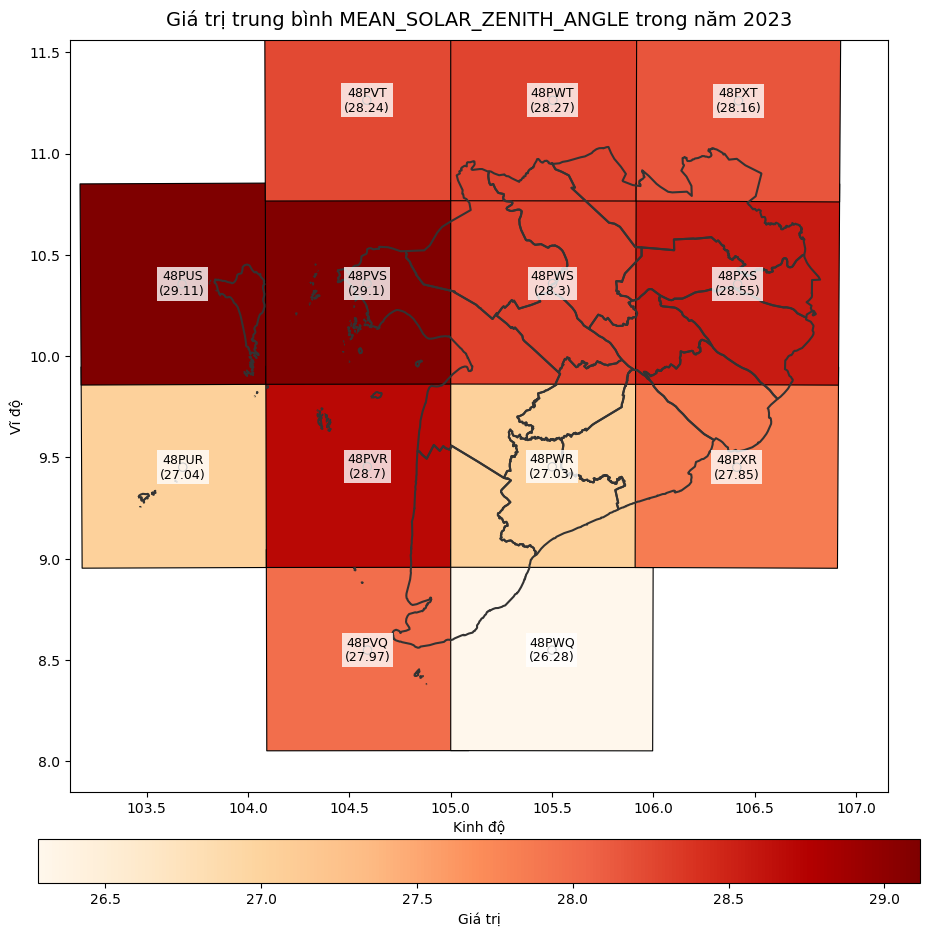

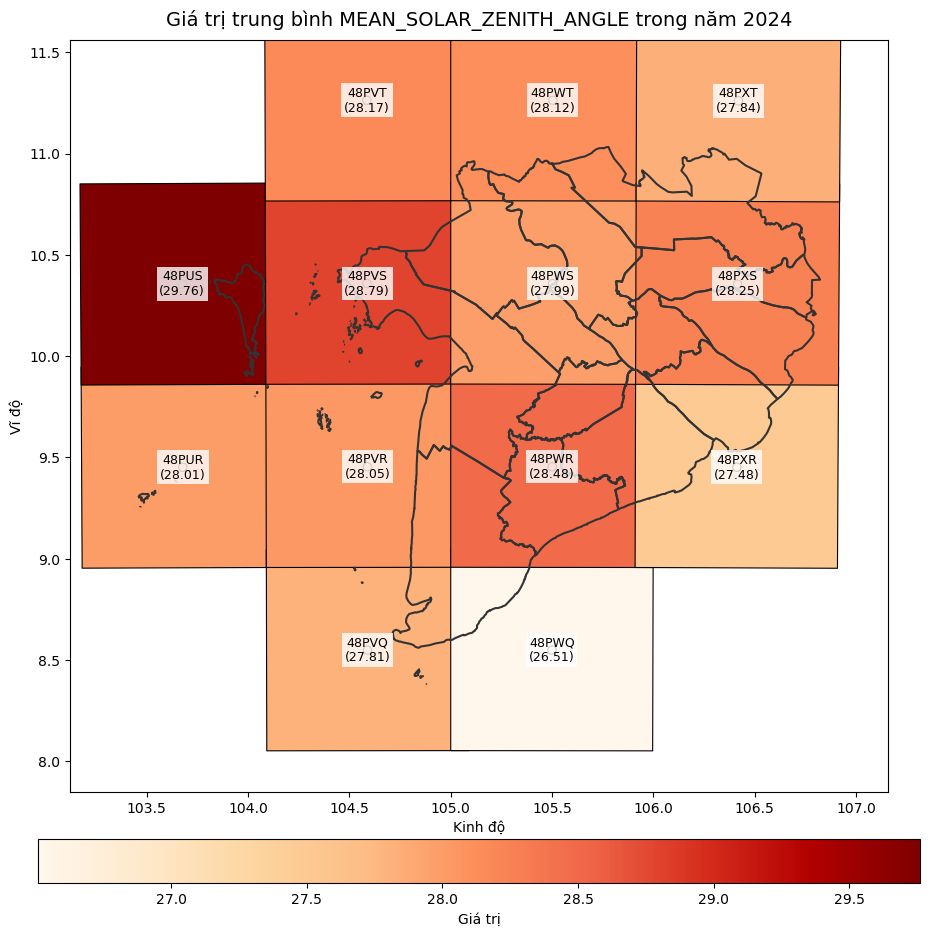

In [16]:
file = 'mean_MEAN_SOLAR_ZENITH_ANGLE.csv'
df = pd.read_csv(file)
for year in df['YEAR'].unique():
    columns = df.columns.tolist()
    df_year = df[df['YEAR'] == year]
    df_mean = df_year.groupby('AREA')[columns[-1]].mean().reset_index()
    df_mean = df_mean.rename(columns={
        'AREA': 'MGRS_Tile',            # Đổi tên cột nhóm
        columns[-1]: 'Frequency'         # Đổi tên cột giá trị trung bình
    })
    visualizer = Sentinel2Visualizer(
    df=df_mean,
    vietnam_file="gadm41_VNM_1.json",
    mgrs_file="sentinel2_grid.geojson",
    title=f"Giá trị trung bình {columns[-1]} trong năm {year}"
    )
    visualizer.run()

### Thống kê trung bình theo năm

- GRANULE_MEAN_AOT: giá trị cao hơn ở các vùng phía Tây và giảm dần về phía Đông. Các khu vực phía Đông gần biển có không khí trong hơn do gió biển làm khuếch tán aerosol. Mặt bằng chung có thể chịu ảnh hưởng từ khí thải giao thông, khu công nghiệp và hoạt động đốt nông nghiệp, tuy nhiên các giá trị AOT nhìn chung vẫn ở mức thấp, phản ánh chất lượng không khí tương đối tốt.

- CLOUDY_PIXEL_PERCENTAGE: dữ liệu đã loại bỏ các mẫu có độ che phủ mây > 50%. Tuy nhiên, tỷ lệ mây trung bình vẫn dao động khoảng 20–30%, có thể gây khó khăn cho việc tính toán một số đặc trưng, nhưng nhìn chung vẫn nằm trong ngưỡng an toàn.

- GRANULE_MEAN_WV: giá trị trung bình dao động quanh 4 g/cm² (tương đương ~40 kg/m²), phản ánh hàm lượng hơi nước cao đặc trưng cho khu vực nhiệt đới ẩm như Đồng bằng sông Cửu Long

- OZON_VALUE: trung bình từ 255-260, nhìn chung vùng nhiệt đới thì tầng ozon khá mỏng so với các khu vực khác nguyên dân do bức xạ mặt trời cao dẫn đến không khí tầng đối lưu mạng làm suy yếu ozon tầng bình lưu

- THIN_CIRRUS_PERCENTAGE: mây cirrus chủ yếu tập trung ở ngoài biển hơn đất liền, chắc nguyên nhân do ngoài biển độ ẩm cao và nhiệt độ thấp, tạo điều kiện hình thành nên các tinh thể băng nhiều hơn làm cho lượng mây cirrus dày đặc

- VEGETALBLE_PERCENTAGE - WATER_PERCENTAGE: các giá trị bình thường, đúng với khu vực

- SNOW_ICE_PERCENTAGE: không liên quan vì vùng Đồng bằng SCL không có tuyết, giá trị tính nhầm cho màu của Cloud

- SOLAR_ZENITH_ANGLE: chỉ thể hiện góc chụp tại các thời điểm rời rạc, không quan trọng lắm 

### Thống kê biến động ngày

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

file = "sentinel2_features.csv"
# Đọc file
try:
    df = pd.read_csv(file)
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {file}. Vui lòng kiểm tra lại đường dẫn.")

# Tạo các cột thời gian
df['YEAR'] = df['PRODUCT_ID'].str[11:15]
df['MONTH'] = df['PRODUCT_ID'].str[15:17]
df['DAY'] = df['PRODUCT_ID'].str[17:19]
df['DATE'] = pd.to_datetime(df['YEAR'] + '-' + df['MONTH'] + '-' + df['DAY'])
df = df.sort_values('DATE')

# Danh sách vùng (tile)
list_areas = [
    None, '48PVT', '48PWT', '48PXT',
    '48PUS', '48PVS', '48PWS', '48PXS',
    '48PUR', '48PVR', '48PWR', '48PXR',
    None, '48PVQ', '48PWQ', None
]

# Tạo thư mục lưu ảnh
output_dir = "phan_tich_don_bien"
os.makedirs(output_dir, exist_ok=True)

# Vòng lặp qua từng feature
for feature in df.columns:
    if feature not in ['PRODUCT_ID', '_source_file', 'AREA', 'YEAR', 'MONTH', 'DAY', 'DATE']:
        grid_data = np.array(list_areas).reshape(4, 4)
        fig, axs = plt.subplots(4, 4, figsize=(18, 15))
        # Khoảng y chung cho feature
        min_feature = df[feature].min()
        max_feature = df[feature].max()
        
        for i in range(4):
            for j in range(4):
                tile_name = grid_data[i, j]
                ax = axs[i, j]

                if tile_name is None:
                    ax.text(0.5, 0.5, 'NONE', transform=ax.transAxes, ha='center', va='center', fontsize=12, color='gray')
                    ax.set_title(f"({i},{j}) - No Data")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

                subset = df[df['AREA'] == tile_name].copy()

                if not subset.empty:
                    ax.plot(subset['DATE'], subset[feature], marker='o', linestyle='-', markersize=3, linewidth=1)
                    ax.set_title(f"{tile_name} (n={len(subset)})", fontsize=10)
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(min_feature, max_feature)  # y cố định cho feature
                    ax.tick_params(axis='x', rotation=45, labelsize=8)
                    ax.tick_params(axis='y', labelsize=8)
                else:
                    ax.text(0.5, 0.5, f'Tile {tile_name}\n(No Data)', transform=ax.transAxes, ha='center', va='center', fontsize=10, color='red')
                    ax.set_xticks([])
                    ax.set_yticks([])

                if i < 3:
                    ax.set_xlabel("")
                else:
                    ax.set_xlabel("Thời gian", fontsize=9)
                if j > 0:
                    ax.set_ylabel("")
                else:
                    ax.set_ylabel(feature, fontsize=9)

        fig.suptitle(f"Biến động theo thời gian: {feature} trên Lưới Tiles 4x4", fontsize=18, y=0.995)
        plt.tight_layout()

        # 👉 Lưu ảnh thay vì hiển thị
        output_path = os.path.join(output_dir, f"{feature}.png")
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close(fig)  # Giải phóng bộ nhớ

        print(f"✅ Đã lưu: {output_path}")


✅ Đã lưu: phan_tich_don_bien\GRANULE_MEAN_AOT.png
✅ Đã lưu: phan_tich_don_bien\GRANULE_MEAN_WV.png
✅ Đã lưu: phan_tich_don_bien\OZONE_VALUE.png
✅ Đã lưu: phan_tich_don_bien\CLOUDY_PIXEL_PERCENTAGE.png
✅ Đã lưu: phan_tich_don_bien\THIN_CIRRUS_PERCENTAGE.png
✅ Đã lưu: phan_tich_don_bien\VEGETATION_PERCENTAGE.png
✅ Đã lưu: phan_tich_don_bien\MEAN_SOLAR_ZENITH_ANGLE.png
✅ Đã lưu: phan_tich_don_bien\WATER_PERCENTAGE.png
✅ Đã lưu: phan_tich_don_bien\SNOW_ICE_PERCENTAGE.png


In [7]:
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# --- Đọc dữ liệu ---
file = "sentinel2_features.csv"
try:
    df = pd.read_csv(file)
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {file}. Vui lòng kiểm tra lại đường dẫn.")

# --- Chuẩn hóa thời gian ---
df['YEAR'] = df['PRODUCT_ID'].str[11:15]
df['MONTH'] = df['PRODUCT_ID'].str[15:17]
df['DAY'] = df['PRODUCT_ID'].str[17:19]
df['DATE'] = pd.to_datetime(df['YEAR'] + '-' + df['MONTH'] + '-' + df['DAY'])
df = df.sort_values('DATE')

# --- Danh sách khu vực ---
list_areas = [
    None, '48PVT', '48PWT', '48PXT',
    '48PUS', '48PVS', '48PWS', '48PXS',
    '48PUR', '48PVR', '48PWR', '48PXR',
    None, '48PVQ', '48PWQ', None
]

# --- Thư mục lưu ---
output_dir = "phan_tich_theo_nam"
os.makedirs(output_dir, exist_ok=True)

# --- Các năm và khoảng thời gian chung ---
years = sorted(df['YEAR'].unique())

# --- Lặp qua từng feature ---
for feature in tqdm(df.columns, desc="Features"):
    if feature not in ['PRODUCT_ID', '_source_file', 'AREA', 'YEAR', 'MONTH', 'DAY', 'DATE']:
        # Khoảng y chung cho feature
        min_feature = df[feature].min()
        max_feature = df[feature].max()

        grid_data = np.array(list_areas).reshape(4, 4)

        # Lặp qua từng năm
        for year in tqdm(years, desc=f"Year for {feature}", leave=False):
            df_year = df[df['YEAR'] == year].copy()
            if df_year.empty:
                continue

            fig, axs = plt.subplots(4, 4, figsize=(18, 15))

            for i in range(4):
                for j in range(4):
                    tile_name = grid_data[i, j]
                    ax = axs[i, j]

                    if tile_name is None:
                        ax.text(0.5, 0.5, 'NONE', transform=ax.transAxes,
                                ha='center', va='center', fontsize=12, color='gray')
                        ax.set_title(f"({i},{j}) - No Data")
                        ax.set_xticks([])
                        ax.set_yticks([])
                        continue

                    subset = df_year[df_year['AREA'] == tile_name].copy()
                    if not subset.empty:
                        ax.plot(subset['DATE'], subset[feature],
                                marker='o', linestyle='-', markersize=3, linewidth=1)
                        ax.set_title(f"{tile_name} (n={len(subset)})", fontsize=10)
                        ax.grid(True, alpha=0.3)
                        ax.set_ylim(min_feature, max_feature)  # y cố định cho feature
                        ax.tick_params(axis='x', rotation=45, labelsize=8)
                        ax.tick_params(axis='y', labelsize=8)
                    else:
                        ax.text(0.5, 0.5, f'Tile {tile_name}\n(No Data)',
                                transform=ax.transAxes, ha='center', va='center',
                                fontsize=10, color='red')
                        ax.set_xticks([])
                        ax.set_yticks([])

                    if i < 3:
                        ax.set_xlabel("")
                    else:
                        ax.set_xlabel("Thời gian", fontsize=9)
                    if j > 0:
                        ax.set_ylabel("")
                    else:
                        ax.set_ylabel(feature, fontsize=9)

            fig.suptitle(f"Biến động {feature} trong năm {year} trên Lưới Tiles 4x4",
                         fontsize=18, y=0.995)
            plt.tight_layout()

            # Lưu ảnh
            filename = f"{feature}_year_{year}.png"
            filepath = os.path.join(output_dir, filename)
            fig.savefig(filepath, dpi=300)
            plt.close(fig)


Features: 100%|██████████| 16/16 [03:51<00:00, 14.47s/it]


- GRANULE_MEAN_AOT: chỉ tăng mạnh ở tháng 4 và giảm dần về cuối năm, nguyên nhân chủ yếu thói quen đốt rơm của người dân sau khi thu hoạch, vì đây là thời điểm cuối mùa khô, các nơi tập trung ở các vùng ven phía tây khu vực, về cuối năm là mùa mưa nên không khí sẽ ít có khả năng bị đục hơn

- CLOUDY_PIXEL_PERCENTAGE: rải rác nhiều giá trị khác nhau không có xu hướng cụ thể

- GRANULE_MEAN_WV: thấp ở đầu năm (mùa khô), tăng ở giữa và cuối năm (mùa mưa)

- OZON_VALUE: cao ở đầu năm (mùa khô), tăng ở giữa và giảm ở cuối năm, nguyên nhân do lượng bức xạ ở đầu năm và cuối năm rất mạnh, giữa năm là mùa mưa nên bức xạ yếu đi -> ozon dày hơn

- THIN_CIRRUS_PERCENTAGE: mây cirrus chủ yếu tập trung ở ngoài biển hơn đất liền, chắc nguyên nhân do ngoài biển độ ẩm cao và nhiệt độ thấp, tạo điều kiện hình thành nên các tinh thể băng nhiều hơn làm cho lượng mây cirrus dày đặc

- VEGETALBLE_PERCENTAGE: thấp ở tháng 3,4 (thu hoạch vụ mùa Đông Xuân) và tháng 9, 10 (thu hoạch vụ mùa và hè thu)

- WATER_PERCENTAGE: cao ở khu vực ven biển, thấp ở các tỉnh không giáp biển

- SOLAR_ZENITH_ANGLE: thấp nhất ở tháng 5, 8 (lên thiên đỉnh), và theo chu kỳ năm

### 🌾 Ba vụ lúa chính tại Đồng bằng sông Cửu Long và đặc điểm của từng vụ



Đồng bằng sông Cửu Long hiện có **3 vụ lúa chính** là: **vụ mùa**, **vụ đông xuân** và **vụ hè thu**.

---

🌧️ Vụ mùa
- **Thời gian gieo trồng:** Đầu mùa mưa *(tháng 5 – tháng 6)*  
- **Thời gian thu hoạch:** Cuối mùa mưa *(tháng 11)*  
- **Đặc điểm:**  
  - Thích hợp trồng các giống lúa địa phương dài ngày, thích nghi với nước sâu.  

- **Giống lúa tiêu biểu:**  
  - VND404, VND95-19, Nàng Thơm Chợ Đào 5, Nàng Hương 2, MTL250, MTL392, MTL449, …

---

🌤️ Vụ đông xuân
- **Thời gian gieo trồng:** Sau khi vụ mùa kết thúc *(tháng 11 – tháng 12)*  
- **Thời gian thu hoạch:** Đầu tháng 4  
- **Đặc điểm:**  
  - Là vụ lúa mới, ngắn ngày, cho năng suất cao.  

- **Giống lúa chủ lực:**  
  - OM 6162, OMCS 2000, OM 5472, OM 6677, OM 4218  
  - Ngoài ra còn có: OM 5451, OM 8232, OM 4101, OM 3995, …

---

☀️ Vụ hè thu
- **Thời gian gieo trồng:** Bắt đầu từ tháng 4  
- **Thời gian thu hoạch:** Kết thúc vào tháng 8  
- **Đặc điểm:**  
  - Là vụ lúa ngắn ngày, có diện tích canh tác khoảng **1,1 triệu ha**.  
  - Thích hợp gieo trồng các giống lúa năng suất cao, chống chịu tốt.  

- **Giống lúa phổ biến:**  
  - OMCS 2000, OMCS21, ND404, VND95-19, MTL250, MTL392, MTL449, …


## Đa biến

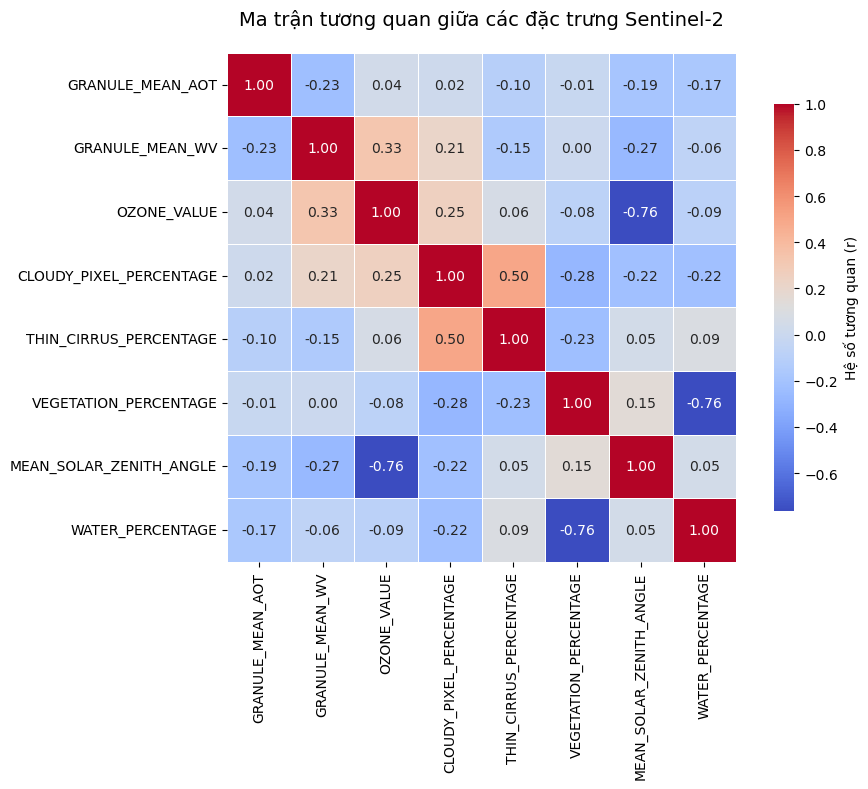

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dữ liệu
file = "sentinel2_features.csv"
df = pd.read_csv(file)

# Tính ma trận tương quan (loại bỏ các cột không phải đặc trưng số)
df_corr = df.drop(columns=['PRODUCT_ID', '_source_file', 'AREA', 'SNOW_ICE_PERCENTAGE']).corr()

# Vẽ heatmap có số corr
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr,
    annot=True,           # Hiển thị số trong ô
    fmt=".2f",            # Giới hạn 2 chữ số sau dấu thập phân
    cmap='coolwarm',      # Màu sắc
    linewidths=0.5,       # Đường kẻ giữa các ô
    square=True,          # Các ô vuông vức
    cbar_kws={'shrink': 0.8, 'label': 'Hệ số tương quan (r)'}
)

plt.title('Ma trận tương quan giữa các đặc trưng Sentinel-2', pad=20, fontsize=14)
plt.tight_layout()
plt.show()


### Tương quan Nghịch Mạnh (Negative Correlation)
OZONE_VALUE & MEAN_SOLAR_ZENITH_ANGLE: r=−0.76
- Ozone tổng cột bị chi phối bởi chu kỳ mùa khi Góc Z nhỏ (Mặt Trời lên cao nhất, mùa hè), tuy nhiên ở đbscl là mùa mưa -> lượng bức xạ nhiệt yếu dưới tầng đối lưu -> ozon tầng bình lưu dày

WATER_PERCENTAGE & VEGETATION_PERCENTAGE: r=−0.76

- Khi diện tích bị nước chiếm lĩnh (Water) tăng lên, thì diện tích bị thảm thực vật (Vegetation) chiếm lĩnh sẽ giảm xuống, phản ánh sự chuyển đổi giữa ruộng lúa (vegetation) và kênh rạch/vùng ngập/nuôi trồng thủy sản (water).

### Tương quan Thuận Mạnh (Positive Correlation)
OZONE_VALUE & GRANULE_MEAN_WV (Hơi nước): r=0.33

- Ozone tầng bình lưu và hơi nước tầng đối lưu đều có xu hướng tăng, hoặc cả hai đều bị ảnh hưởng bởi cùng một mô hình lưu thông khí quyển.

CLOUDY_PIXEL_PERCENTAGE & THIN_CIRRUS_PERCENTAGE: r=0.50
- Tỷ lệ mây dày (Cloudy) tăng, tỷ lệ mây ti (Thin Cirrus) cũng có xu hướng tăng theo. Cả hai đều là yếu tố gây cản trở chất lượng ảnh.